In [69]:
# ================================================================
# NMT ARCHITECTURE COMPARATIVE ANALYSIS
# ================================================================
# Architectures:
#   1. Vanilla RNN Seq2Seq
#   2. GRU Encoder-Decoder without Attention
#   3. GRU Encoder-Decoder with Bahdanau Additive Attention
#   4. GRU Encoder-Decoder with Luong Multiplicative Attention
#
# Dataset:
#   ManyThings.org Anki Translation Dataset
#
# Default language pair:
#   English -> French
#
# Outputs:
#   - trained model checkpoints
#   - CSV results
#   - loss curves
#   - BLEU/latency/PPL plots
#   - attention heatmaps
#   - qualitative translation examples
#   - NMT_Comparative_Analysis_Report.md
#
# Designed for a SINGLE Google Colab cell.
# ================================================================

# ================================================================
# 0. CONFIGURATION
# ================================================================

import os

# Deterministic CUDA configuration must be set before substantial
# CUDA work begins.
os.environ["PYTHONHASHSEED"] = "4"
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

import re
import gc
import csv
import math
import json
import time
import random
import zipfile
import hashlib
import urllib.request
from pathlib import Path
from collections import Counter
from dataclasses import dataclass, asdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from nltk.translate.bleu_score import corpus_bleu, sentence_bleu, SmoothingFunction

In [70]:
# ------------------------------------------------
# Main experiment configuration
# ------------------------------------------------

SEED = 4

# Choose:
#   "fra" = English -> French
LANGUAGE_PAIR = "fra"

# DATASET:
DATASET_URLS = {
    "fra": "https://www.manythings.org/anki/fra-eng.zip",
    "spa": "https://www.manythings.org/anki/spa-eng.zip",
}

DATASET_NAMES = {
    "fra": "English-French",
    "spa": "English-Spanish",
}

DATA_DIR = Path("nmt_comparative_analysis/data/")
PLOT_DIR = Path("nmt_comparative_analysis/plots/")
RESULT_DIR = Path("nmt_comparative_analysis/results/")
CHECKPOINT_DIR = Path("nmt_comparative_analysis/checkpoints/")
OUTPUT_DIR = Path("nmt_comparative_analysis/")

DATA_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR.mkdir(parents=True, exist_ok=True)
RESULT_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# HYPERPARAMETERS:
EMBEDDING_DIM = 256
HIDDEN_DIM = 256
MAX_SEQ_LEN = 30
MAX_VOCAB_SIZE = 20000
MIN_FREQ = 2
MAX_PAIRS = 50000  # Set to None for all pairs.

# TRAINING:
BATCH_SIZE = 64
LEARNING_RATE = 0.001
OPTIMIZER_NAME = "Adam"
LOSS_NAME = "CrossEntropyLoss"
CLIP_VALUE = 1.0
NUM_EPOCHS = 10
TEACHER_FORCING_START = 1.0
TEACHER_FORCING_END = 0.5

# EVALUATION:
MAX_GENERATION_LEN = 30

# DATA SPLIT:
TRAIN_RATIO = 0.8
VAL_RATIO = 0.1
TEST_RATIO = 0.1

# MISCELLANEOUS:
NUM_WORKERS = 2  # Number of DataLoader workers.
STRICT_DETERMINISM = True # Try to use deterministic CUDA algorithms where available.


In [71]:
# ================================================================
# 1. REPRODUCIBILITY
# ================================================================

def seed_everything(seed=4):
    """
    Enforce reproducibility across Python, NumPy and PyTorch.
    """
    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    os.environ["PYTHONHASHSEED"] = str(seed)

    # cuDNN deterministic behavior.
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    if STRICT_DETERMINISM:
        try:
            torch.use_deterministic_algorithms(True)
        except Exception as exc:
            print(
                "Warning: torch.use_deterministic_algorithms(True) "
                f"could not be fully enabled: {exc}"
            )


seed_everything(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("=" * 70)
print("NMT COMPARATIVE ANALYSIS")
print("=" * 70)
print(f"Seed:       {SEED}")
print(f"Device:     {DEVICE}")
print(f"Language:   {DATASET_NAMES[LANGUAGE_PAIR]}")
print(f"Max pairs:  {MAX_PAIRS if MAX_PAIRS is not None else 'ALL'}")
print("=" * 70)

NMT COMPARATIVE ANALYSIS
Seed:       4
Device:     cuda
Language:   English-French
Max pairs:  50000


In [72]:
# ================================================================
# 2. DOWNLOAD MANYTHINGS DATASET
# ================================================================

def download_dataset(language_pair):
    url = DATASET_URLS[language_pair]

    zip_path = DATA_DIR / f"{language_pair}-eng.zip"
    extract_dir = DATA_DIR / f"{language_pair}-eng"

    if not zip_path.exists():
        print(f"\nDownloading dataset:")
        print(url)

        # Add a more detailed User-Agent header to avoid HTTP Error 406 (Not Acceptable)
        headers = {
            'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'
        }
        req = urllib.request.Request(url, headers=headers)
        with urllib.request.urlopen(req) as response:
            with open(zip_path, 'wb') as out_file:
                out_file.write(response.read())

        print(f"Downloaded: {zip_path}")

    if not extract_dir.exists():
        extract_dir.mkdir(parents=True, exist_ok=True)

        print("Extracting dataset...")
        with zipfile.ZipFile(zip_path, "r") as zf:
            zf.extractall(extract_dir)

    # Locate .txt file robustly.
    txt_files = list(extract_dir.rglob("*.txt"))

    if not txt_files:
        raise FileNotFoundError(
            f"No translation .txt file found in {extract_dir}"
        )

    # Prefer the expected filename.
    expected_name = f"{language_pair}-eng.txt"

    for file_path in txt_files:
        if file_path.name.lower() == expected_name:
            return file_path

    return txt_files[0]


DATASET_FILE = download_dataset(LANGUAGE_PAIR)

print(f"\nDataset file: {DATASET_FILE}")


Dataset file: nmt_comparative_analysis/data/fra-eng/fra.txt


In [73]:
# ================================================================
# 3. TEXT NORMALIZATION
# ================================================================

def normalize_text(text):
    """
    Conservative text normalization.

    We preserve accented characters because French/Spanish
    translation quality depends on them.
    """
    text = text.strip().lower()

    # Normalize Unicode apostrophes and quotes.
    replacements = {
        "\u2018": "'",
        "\u2019": "'",
        "\u201c": '"',
        "\u201d": '"',
        "\u00a0": " ",
    }

    for old, new in replacements.items():
        text = text.replace(old, new)

    # Collapse whitespace.
    text = re.sub(r"\s+", " ", text)

    return text.strip()

In [74]:
# ================================================================
# 4. READ AND CLEAN PARALLEL CORPUS
# ================================================================

def load_parallel_corpus(file_path):
    """
    ManyThings format:

        English<TAB>Target<TAB>Attribution

    We only use the first two columns.
    """

    pairs = []

    with open(
        file_path,
        "r",
        encoding="utf-8"
    ) as f:

        for line in f:
            line = line.strip()

            if not line:
                continue

            parts = line.split("\t")

            if len(parts) < 2:
                continue

            english = normalize_text(parts[0])
            target = normalize_text(parts[1])

            if not english or not target:
                continue

            pairs.append(
                (english, target)
            )

    return pairs


all_pairs = load_parallel_corpus(DATASET_FILE)

print(f"Raw usable sentence pairs: {len(all_pairs):,}")

Raw usable sentence pairs: 240,521


In [75]:
# ================================================================
# 5. DATA CLEANING AND LENGTH FILTERING
# ================================================================

def tokenize(text):
    """
    Simple whitespace tokenizer.

    This intentionally avoids an external tokenizer so the
    experimental setup remains deterministic and reproducible.
    """
    return text.split()


def filter_pairs(pairs, max_len):
    filtered = []

    for src, trg in pairs:

        src_tokens = tokenize(src)
        trg_tokens = tokenize(trg)

        # +2 for SOS/EOS.
        if len(src_tokens) + 2 > max_len:
            continue

        if len(trg_tokens) + 2 > max_len:
            continue

        filtered.append(
            (src, trg)
        )

    return filtered


all_pairs = filter_pairs(
    all_pairs,
    MAX_SEQ_LEN
)

print(
    f"After sequence-length filtering: "
    f"{len(all_pairs):,}"
)



After sequence-length filtering: 240,486


In [76]:
# ================================================================
# 6. DETERMINISTIC SUBSAMPLING
# ================================================================

def deterministic_sample(pairs, max_pairs, seed):
    """
    RandomState(seed) is used explicitly to satisfy the requested
    random_state=4 experimental protocol.
    """

    if max_pairs is None or max_pairs >= len(pairs):
        return pairs

    rng = np.random.RandomState(seed)

    indices = rng.choice(
        len(pairs),
        size=max_pairs,
        replace=False
    )

    indices = np.sort(indices)

    return [
        pairs[i]
        for i in indices
    ]


pairs = deterministic_sample(
    all_pairs,
    MAX_PAIRS,
    SEED
)

print(
    f"Pairs selected for experiment: "
    f"{len(pairs):,}"
)


Pairs selected for experiment: 50,000


In [77]:
# ================================================================
# 7. DETERMINISTIC 80/10/10 TRAIN/VAL/TEST SPLIT
# ================================================================

def split_dataset(pairs, seed=4):
    """
    Explicit random_state=4 style split.

    80% train
    10% validation
    10% test
    """

    rng = np.random.RandomState(seed)

    indices = np.arange(len(pairs))
    rng.shuffle(indices)

    n = len(indices)

    train_end = int(
        TRAIN_RATIO * n
    )

    val_end = train_end + int(
        VAL_RATIO * n
    )

    train_indices = indices[:train_end]
    val_indices = indices[train_end:val_end]
    test_indices = indices[val_end:]

    train_pairs = [pairs[i] for i in train_indices]
    val_pairs = [pairs[i] for i in val_indices]
    test_pairs = [pairs[i] for i in test_indices]

    return (
        train_pairs,
        val_pairs,
        test_pairs
    )


train_pairs, val_pairs, test_pairs = split_dataset(
    pairs,
    SEED
)

print("\nDataset split:")
print(f"Train: {len(train_pairs):,}")
print(f"Val:   {len(val_pairs):,}")
print(f"Test:  {len(test_pairs):,}")



Dataset split:
Train: 40,000
Val:   5,000
Test:  5,000


In [78]:
# ================================================================
# 8. VOCABULARY
# ================================================================

PAD_TOKEN = "<PAD>"
SOS_TOKEN = "<SOS>"
EOS_TOKEN = "<EOS>"
UNK_TOKEN = "<UNK>"

SPECIAL_TOKENS = [
    PAD_TOKEN,
    SOS_TOKEN,
    EOS_TOKEN,
    UNK_TOKEN,
]


class Vocabulary:

    def __init__(
        self,
        max_size=None,
        min_freq=1
    ):
        self.max_size = max_size
        self.min_freq = min_freq

        self.token_to_idx = {}
        self.idx_to_token = {}

        for token in SPECIAL_TOKENS:
            self._add_token(token)

    def _add_token(self, token):
        if token not in self.token_to_idx:

            idx = len(self.token_to_idx)

            self.token_to_idx[token] = idx
            self.idx_to_token[idx] = token

    def build(self, sentences):

        counter = Counter()

        for sentence in sentences:

            for token in tokenize(sentence):
                counter[token] += 1

        tokens = [
            token
            for token, count in counter.items()
            if count >= self.min_freq
        ]

        # Most frequent tokens first.
        tokens.sort(
            key=lambda token: (
                -counter[token],
                token
            )
        )

        if self.max_size is not None:

            available_slots = (
                self.max_size -
                len(SPECIAL_TOKENS)
            )

            tokens = tokens[:max(0, available_slots)]

        for token in tokens:
            self._add_token(token)

    def encode(
        self,
        sentence,
        max_len
    ):

        tokens = tokenize(sentence)

        ids = [
            self.token_to_idx[SOS_TOKEN]
        ]

        unk_id = self.token_to_idx[UNK_TOKEN]

        for token in tokens:

            ids.append(
                self.token_to_idx.get(
                    token,
                    unk_id
                )
            )

        ids.append(
            self.token_to_idx[EOS_TOKEN]
        )

        # Truncate while preserving EOS.
        ids = ids[:max_len]

        if ids[-1] != self.token_to_idx[EOS_TOKEN]:
            ids[-1] = self.token_to_idx[EOS_TOKEN]

        # Pad.
        ids += [
            self.token_to_idx[PAD_TOKEN]
        ] * (max_len - len(ids))

        return ids

    def decode(
        self,
        ids,
        remove_special=True
    ):

        tokens = []

        for idx in ids:

            token = self.idx_to_token.get(
                int(idx),
                UNK_TOKEN
            )

            if token == EOS_TOKEN:
                break

            if remove_special and token in SPECIAL_TOKENS:
                continue

            tokens.append(token)

        return tokens

    def __len__(self):
        return len(self.token_to_idx)


src_vocab = Vocabulary(
    max_size=MAX_VOCAB_SIZE,
    min_freq=MIN_FREQ
)

trg_vocab = Vocabulary(
    max_size=MAX_VOCAB_SIZE,
    min_freq=MIN_FREQ
)

src_vocab.build(
    src for src, _ in train_pairs
)

trg_vocab.build(
    trg for _, trg in train_pairs
)

print("\nVocabulary:")
print(f"Source vocabulary: {len(src_vocab):,}")
print(f"Target vocabulary: {len(trg_vocab):,}")


SRC_PAD_IDX = src_vocab.token_to_idx[PAD_TOKEN]
SRC_SOS_IDX = src_vocab.token_to_idx[SOS_TOKEN]
SRC_EOS_IDX = src_vocab.token_to_idx[EOS_TOKEN]

TRG_PAD_IDX = trg_vocab.token_to_idx[PAD_TOKEN]
TRG_SOS_IDX = trg_vocab.token_to_idx[SOS_TOKEN]
TRG_EOS_IDX = trg_vocab.token_to_idx[EOS_TOKEN]



Vocabulary:
Source vocabulary: 7,846
Target vocabulary: 10,166


In [79]:
# ================================================================
# 9. PYTORCH DATASET
# ================================================================

class TranslationDataset(Dataset):

    def __init__(
        self,
        pairs,
        src_vocab,
        trg_vocab,
        max_len
    ):
        self.pairs = pairs
        self.src_vocab = src_vocab
        self.trg_vocab = trg_vocab
        self.max_len = max_len

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):

        src_text, trg_text = self.pairs[idx]

        src_ids = self.src_vocab.encode(
            src_text,
            self.max_len
        )

        trg_ids = self.trg_vocab.encode(
            trg_text,
            self.max_len
        )

        return {
            "src": torch.tensor(
                src_ids,
                dtype=torch.long
            ),
            "trg": torch.tensor(
                trg_ids,
                dtype=torch.long
            ),
            "src_text": src_text,
            "trg_text": trg_text,
        }


train_dataset = TranslationDataset(
    train_pairs,
    src_vocab,
    trg_vocab,
    MAX_SEQ_LEN
)

val_dataset = TranslationDataset(
    val_pairs,
    src_vocab,
    trg_vocab,
    MAX_SEQ_LEN
)

test_dataset = TranslationDataset(
    test_pairs,
    src_vocab,
    trg_vocab,
    MAX_SEQ_LEN
)


def create_dataloader(
    dataset,
    shuffle,
    seed
):

    generator = torch.Generator()

    generator.manual_seed(seed)

    return DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        num_workers=NUM_WORKERS,
        pin_memory=(DEVICE.type == "cuda"),
        generator=generator,
        drop_last=False,
    )


train_loader = create_dataloader(
    train_dataset,
    shuffle=True,
    seed=SEED
)

val_loader = create_dataloader(
    val_dataset,
    shuffle=False,
    seed=SEED
)

test_loader = create_dataloader(
    test_dataset,
    shuffle=False,
    seed=SEED
)

In [80]:

# ================================================================
# 10. MODEL COMPONENTS
# ================================================================

class VanillaRNNEncoder(nn.Module):

    def __init__(
        self,
        input_dim,
        embedding_dim,
        hidden_dim
    ):
        super().__init__()

        self.embedding = nn.Embedding(
            input_dim,
            embedding_dim,
            padding_idx=SRC_PAD_IDX
        )

        self.rnn = nn.RNN(
            embedding_dim,
            hidden_dim,
            batch_first=True
        )

    def forward(self, src):

        embedded = self.embedding(src)

        outputs, hidden = self.rnn(
            embedded
        )

        return outputs, hidden


class VanillaRNNDecoder(nn.Module):

    def __init__(
        self,
        output_dim,
        embedding_dim,
        hidden_dim
    ):
        super().__init__()

        self.output_dim = output_dim

        self.embedding = nn.Embedding(
            output_dim,
            embedding_dim,
            padding_idx=TRG_PAD_IDX
        )

        self.rnn = nn.RNN(
            embedding_dim,
            hidden_dim,
            batch_first=True
        )

        self.fc_out = nn.Linear(
            hidden_dim,
            output_dim
        )

    def forward(
        self,
        input_token,
        hidden
    ):

        input_token = input_token.unsqueeze(1)

        embedded = self.embedding(
            input_token
        )

        output, hidden = self.rnn(
            embedded,
            hidden
        )

        prediction = self.fc_out(
            output.squeeze(1)
        )

        return prediction, hidden


class GRUEncoder(nn.Module):

    def __init__(
        self,
        input_dim,
        embedding_dim,
        hidden_dim
    ):
        super().__init__()

        self.embedding = nn.Embedding(
            input_dim,
            embedding_dim,
            padding_idx=SRC_PAD_IDX
        )

        self.gru = nn.GRU(
            embedding_dim,
            hidden_dim,
            batch_first=True
        )

    def forward(self, src):

        embedded = self.embedding(src)

        outputs, hidden = self.gru(
            embedded
        )

        return outputs, hidden


class GRUDecoder(nn.Module):

    def __init__(
        self,
        output_dim,
        embedding_dim,
        hidden_dim
    ):
        super().__init__()

        self.output_dim = output_dim

        self.embedding = nn.Embedding(
            output_dim,
            embedding_dim,
            padding_idx=TRG_PAD_IDX
        )

        self.gru = nn.GRU(
            embedding_dim,
            hidden_dim,
            batch_first=True
        )

        self.fc_out = nn.Linear(
            hidden_dim,
            output_dim
        )

    def forward(
        self,
        input_token,
        hidden
    ):

        input_token = input_token.unsqueeze(1)

        embedded = self.embedding(
            input_token
        )

        output, hidden = self.gru(
            embedded,
            hidden
        )

        prediction = self.fc_out(
            output.squeeze(1)
        )

        return prediction, hidden


In [81]:
# ================================================================
# 11. BAHDAUNAU ADDITIVE ATTENTION
# ================================================================

class BahdanauAttention(nn.Module):

    """
    Additive attention:

        e_ti =
            v_a^T tanh(
                W_h h_i + W_s s_t
            )

        alpha_ti =
            softmax(e_ti)

        c_t =
            sum_i alpha_ti h_i

    where:
        h_i = encoder hidden state
        s_t = decoder hidden state
    """

    def __init__(
        self,
        hidden_dim
    ):
        super().__init__()

        self.encoder_projection = nn.Linear(
            hidden_dim,
            hidden_dim,
            bias=False
        )

        self.decoder_projection = nn.Linear(
            hidden_dim,
            hidden_dim,
            bias=False
        )

        self.energy_projection = nn.Linear(
            hidden_dim,
            1,
            bias=False
        )

    def forward(
        self,
        decoder_hidden,
        encoder_outputs,
        mask
    ):

        # decoder_hidden:
        # [batch, hidden]
        #
        # encoder_outputs:
        # [batch, src_len, hidden]

        decoder_features = self.decoder_projection(
            decoder_hidden
        ).unsqueeze(1)

        encoder_features = self.encoder_projection(
            encoder_outputs
        )

        energy = torch.tanh(
            encoder_features +
            decoder_features
        )

        energy = self.energy_projection(
            energy
        ).squeeze(-1)

        energy = energy.masked_fill(
            ~mask,
            -1e9
        )

        attention = torch.softmax(
            energy,
            dim=1
        )

        context = torch.bmm(
            attention.unsqueeze(1),
            encoder_outputs
        ).squeeze(1)

        return context, attention


class AttentionDecoder(nn.Module):

    def __init__(
        self,
        output_dim,
        embedding_dim,
        hidden_dim,
        attention
    ):
        super().__init__()

        self.output_dim = output_dim
        self.attention = attention

        self.embedding = nn.Embedding(
            output_dim,
            embedding_dim,
            padding_idx=TRG_PAD_IDX
        )

        self.gru = nn.GRU(
            embedding_dim + hidden_dim,
            hidden_dim,
            batch_first=True
        )

        self.fc_out = nn.Linear(
            embedding_dim +
            hidden_dim +
            hidden_dim,
            output_dim
        )

    def forward(
        self,
        input_token,
        hidden,
        encoder_outputs,
        src_mask
    ):

        input_token = input_token.unsqueeze(1)

        embedded = self.embedding(
            input_token
        )

        decoder_hidden = hidden[-1]

        context, attention = self.attention(
            decoder_hidden,
            encoder_outputs,
            src_mask
        )

        gru_input = torch.cat(
            [
                embedded,
                context.unsqueeze(1)
            ],
            dim=2
        )

        output, hidden = self.gru(
            gru_input,
            hidden
        )

        output = output.squeeze(1)

        prediction = self.fc_out(
            torch.cat(
                [
                    output,
                    context,
                    embedded.squeeze(1)
                ],
                dim=1
            )
        )

        return prediction, hidden, attention

In [82]:
# ================================================================
# 12. LUONG MULTIPLICATIVE ATTENTION
# ================================================================

class LuongAttention(nn.Module):

    """
    General Luong multiplicative attention:

        score(s_t, h_i) =
            s_t^T W_a h_i

        alpha_ti =
            softmax(score(s_t, h_i))

        c_t =
            sum_i alpha_ti h_i
    """

    def __init__(
        self,
        hidden_dim
    ):
        super().__init__()

        self.encoder_projection = nn.Linear(
            hidden_dim,
            hidden_dim,
            bias=False
        )

    def forward(
        self,
        decoder_hidden,
        encoder_outputs,
        mask
    ):

        projected_encoder = self.encoder_projection(
            encoder_outputs
        )

        decoder_hidden = decoder_hidden.unsqueeze(2)

        scores = torch.bmm(
            projected_encoder,
            decoder_hidden
        ).squeeze(2)

        scores = scores.masked_fill(
            ~mask,
            -1e9
        )

        attention = torch.softmax(
            scores,
            dim=1
        )

        context = torch.bmm(
            attention.unsqueeze(1),
            encoder_outputs
        ).squeeze(1)

        return context, attention


In [83]:
# ================================================================
# 13. GENERIC SEQ2SEQ WRAPPERS
# ================================================================

class VanillaRNNSeq2Seq(nn.Module):

    def __init__(
        self,
        src_dim,
        trg_dim,
        embedding_dim,
        hidden_dim
    ):
        super().__init__()

        self.encoder = VanillaRNNEncoder(
            src_dim,
            embedding_dim,
            hidden_dim
        )

        self.decoder = VanillaRNNDecoder(
            trg_dim,
            embedding_dim,
            hidden_dim
        )

    def forward(
        self,
        src,
        trg,
        teacher_forcing_ratio=0.5
    ):

        batch_size = src.size(0)
        trg_len = trg.size(1)
        trg_vocab_size = self.decoder.output_dim

        outputs = torch.zeros(
            batch_size,
            trg_len,
            trg_vocab_size,
            device=src.device
        )

        encoder_outputs, hidden = self.encoder(src)

        input_token = trg[:, 0]

        for t in range(1, trg_len):

            output, hidden = self.decoder(
                input_token,
                hidden
            )

            outputs[:, t] = output

            teacher_force = (
                random.random()
                < teacher_forcing_ratio
            )

            top1 = output.argmax(
                dim=1
            )

            input_token = (
                trg[:, t]
                if teacher_force
                else top1
            )

        return outputs, None


class GRUSeq2Seq(nn.Module):

    def __init__(
        self,
        src_dim,
        trg_dim,
        embedding_dim,
        hidden_dim
    ):
        super().__init__()

        self.encoder = GRUEncoder(
            src_dim,
            embedding_dim,
            hidden_dim
        )

        self.decoder = GRUDecoder(
            trg_dim,
            embedding_dim,
            hidden_dim
        )

    def forward(
        self,
        src,
        trg,
        teacher_forcing_ratio=0.5
    ):

        batch_size = src.size(0)
        trg_len = trg.size(1)
        trg_vocab_size = self.decoder.output_dim

        outputs = torch.zeros(
            batch_size,
            trg_len,
            trg_vocab_size,
            device=src.device
        )

        _, hidden = self.encoder(src)

        input_token = trg[:, 0]

        for t in range(1, trg_len):

            output, hidden = self.decoder(
                input_token,
                hidden
            )

            outputs[:, t] = output

            teacher_force = (
                random.random()
                < teacher_forcing_ratio
            )

            top1 = output.argmax(
                dim=1
            )

            input_token = (
                trg[:, t]
                if teacher_force
                else top1
            )

        return outputs, None


class AttentionSeq2Seq(nn.Module):

    def __init__(
        self,
        src_dim,
        trg_dim,
        embedding_dim,
        hidden_dim,
        attention_type
    ):
        super().__init__()

        self.encoder = GRUEncoder(
            src_dim,
            embedding_dim,
            hidden_dim
        )

        if attention_type == "bahdanau":

            self.attention = BahdanauAttention(
                hidden_dim
            )

        elif attention_type == "luong":

            self.attention = LuongAttention(
                hidden_dim
            )

        else:
            raise ValueError(
                f"Unknown attention type: {attention_type}"
            )

        self.decoder = AttentionDecoder(
            trg_dim,
            embedding_dim,
            hidden_dim,
            self.attention
        )

    def forward(
        self,
        src,
        trg,
        teacher_forcing_ratio=0.5
    ):

        batch_size = src.size(0)
        trg_len = trg.size(1)
        trg_vocab_size = self.decoder.output_dim

        outputs = torch.zeros(
            batch_size,
            trg_len,
            trg_vocab_size,
            device=src.device
        )

        attentions = torch.zeros(
            batch_size,
            trg_len,
            src.size(1),
            device=src.device
        )

        encoder_outputs, hidden = self.encoder(
            src
        )

        src_mask = (
            src != SRC_PAD_IDX
        )

        input_token = trg[:, 0]

        for t in range(1, trg_len):

            output, hidden, attention = (
                self.decoder(
                    input_token,
                    hidden,
                    encoder_outputs,
                    src_mask
                )
            )

            outputs[:, t] = output

            attentions[:, t] = attention

            teacher_force = (
                random.random()
                < teacher_forcing_ratio
            )

            top1 = output.argmax(
                dim=1
            )

            input_token = (
                trg[:, t]
                if teacher_force
                else top1
            )

        return outputs, attentions

In [84]:

# ================================================================
# 14. MODEL FACTORY
# ================================================================

MODEL_NAMES = [
    "Vanilla RNN",
    "GRU Seq2Seq",
    "Bahdanau Attention",
    "Luong Attention",
]


def build_model(model_name):

    if model_name == "Vanilla RNN":

        model = VanillaRNNSeq2Seq(
            len(src_vocab),
            len(trg_vocab),
            EMBEDDING_DIM,
            HIDDEN_DIM
        )

    elif model_name == "GRU Seq2Seq":

        model = GRUSeq2Seq(
            len(src_vocab),
            len(trg_vocab),
            EMBEDDING_DIM,
            HIDDEN_DIM
        )

    elif model_name == "Bahdanau Attention":

        model = AttentionSeq2Seq(
            len(src_vocab),
            len(trg_vocab),
            EMBEDDING_DIM,
            HIDDEN_DIM,
            "bahdanau"
        )

    elif model_name == "Luong Attention":

        model = AttentionSeq2Seq(
            len(src_vocab),
            len(trg_vocab),
            EMBEDDING_DIM,
            HIDDEN_DIM,
            "luong"
        )

    else:
        raise ValueError(
            f"Unknown model: {model_name}"
        )

    return model.to(DEVICE)


In [85]:

# ================================================================
# 15. PARAMETER COUNT
# ================================================================

def count_parameters(model):
    return sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )


# ================================================================
# 16. TEACHER FORCING SCHEDULE
# ================================================================

def teacher_forcing_ratio(epoch, total_epochs):

    if total_epochs <= 1:
        return TEACHER_FORCING_END

    progress = (
        epoch - 1
    ) / (
        total_epochs - 1
    )

    ratio = (
        TEACHER_FORCING_START +
        progress *
        (
            TEACHER_FORCING_END -
            TEACHER_FORCING_START
        )
    )

    return ratio



In [86]:
# ================================================================
# 17. LOSS
# ================================================================

criterion = nn.CrossEntropyLoss(
    ignore_index=TRG_PAD_IDX
)


def calculate_loss(
    outputs,
    targets
):

    output_dim = outputs.size(-1)

    outputs = outputs[:, 1:].reshape(
        -1,
        output_dim
    )

    targets = targets[:, 1:].reshape(
        -1
    )

    return criterion(
        outputs,
        targets
    )


In [87]:
# ================================================================
# 18. TRAINING
# ================================================================

def train_one_epoch(
    model,
    loader,
    optimizer,
    teacher_forcing_ratio
):

    model.train()

    epoch_loss = 0.0

    for batch in loader:

        src = batch["src"].to(
            DEVICE,
            non_blocking=True
        )

        trg = batch["trg"].to(
            DEVICE,
            non_blocking=True
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        outputs, _ = model(
            src,
            trg,
            teacher_forcing_ratio
        )

        loss = calculate_loss(
            outputs,
            trg
        )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            CLIP_VALUE
        )

        optimizer.step()

        epoch_loss += (
            loss.item()
            * src.size(0)
        )

    return epoch_loss / len(loader.dataset)


In [88]:
# ================================================================
# 19. VALIDATION
# ================================================================

@torch.no_grad()
def evaluate_loss(
    model,
    loader
):

    model.eval()

    epoch_loss = 0.0

    for batch in loader:

        src = batch["src"].to(
            DEVICE,
            non_blocking=True
        )

        trg = batch["trg"].to(
            DEVICE,
            non_blocking=True
        )

        # Teacher forcing is used for validation PPL/loss.
        outputs, _ = model(
            src,
            trg,
            teacher_forcing_ratio=1.0
        )

        loss = calculate_loss(
            outputs,
            trg
        )

        epoch_loss += (
            loss.item()
            * src.size(0)
        )

    return epoch_loss / len(loader.dataset)



In [89]:
# ================================================================
# 20. TRAIN MODEL
# ================================================================

def train_model(
    model_name
):

    print("\n")
    print("=" * 70)
    print(f"TRAINING: {model_name}")
    print("=" * 70)

    # Reset seed before each model so initialization is reproducible.
    seed_everything(SEED)

    model = build_model(
        model_name
    )

    optimizer = optim.Adam(
        model.parameters(),
        lr=LEARNING_RATE
    )

    history = {
        "train_loss": [],
        "val_loss": [],
        "teacher_forcing": [],
        "epoch_time_sec": [],
    }

    best_val_loss = float("inf")

    checkpoint_path = (
        CHECKPOINT_DIR /
        (
            model_name.lower()
            .replace(" ", "_")
            .replace("-", "_")
            + ".pt"
        )
    )

    start_total = time.perf_counter()

    for epoch in range(
        1,
        NUM_EPOCHS + 1
    ):

        epoch_start = time.perf_counter()

        tf_ratio = teacher_forcing_ratio(
            epoch,
            NUM_EPOCHS
        )

        train_loss = train_one_epoch(
            model,
            train_loader,
            optimizer,
            tf_ratio
        )

        val_loss = evaluate_loss(
            model,
            val_loader
        )

        epoch_time = (
            time.perf_counter()
            - epoch_start
        )

        history["train_loss"].append(
            train_loss
        )

        history["val_loss"].append(
            val_loss
        )

        history["teacher_forcing"].append(
            tf_ratio
        )

        history["epoch_time_sec"].append(
            epoch_time
        )

        print(
            f"Epoch {epoch:02d}/{NUM_EPOCHS} | "
            f"TF={tf_ratio:.3f} | "
            f"Train={train_loss:.4f} | "
            f"Val={val_loss:.4f} | "
            f"Time={epoch_time:.1f}s"
        )

        if val_loss < best_val_loss:

            best_val_loss = val_loss

            torch.save(
                {
                    "model_state_dict": model.state_dict(),
                    "model_name": model_name,
                    "seed": SEED,
                    "embedding_dim": EMBEDDING_DIM,
                    "hidden_dim": HIDDEN_DIM,
                    "max_seq_len": MAX_SEQ_LEN,
                    "source_vocab": src_vocab.token_to_idx,
                    "target_vocab": trg_vocab.token_to_idx,
                    "best_val_loss": best_val_loss,
                },
                checkpoint_path
            )

    total_time = (
        time.perf_counter()
        - start_total
    )

    # Restore best checkpoint.
    checkpoint = torch.load(
        checkpoint_path,
        map_location=DEVICE,
        weights_only=False
    )

    model.load_state_dict(
        checkpoint["model_state_dict"]
    )

    print(
        f"\nBest validation loss: "
        f"{best_val_loss:.4f}"
    )

    print(
        f"Total training time: "
        f"{total_time / 60:.2f} min"
    )

    return (
        model,
        history,
        total_time
    )

In [90]:
# ================================================================
# 21. GREEDY TRANSLATION
# ================================================================

@torch.no_grad()
def translate_sentence(
    model,
    sentence,
    return_attention=False
):

    model.eval()

    src_ids = src_vocab.encode(
        sentence,
        MAX_SEQ_LEN
    )

    src_tensor = torch.tensor(
        src_ids,
        dtype=torch.long,
        device=DEVICE
    ).unsqueeze(0)

    if isinstance(
        model,
        VanillaRNNSeq2Seq
    ):

        encoder_outputs, hidden = (
            model.encoder(
                src_tensor
            )
        )

        input_token = torch.tensor(
            [TRG_SOS_IDX],
            dtype=torch.long,
            device=DEVICE
        )

        generated = []
        attention_history = []

        for _ in range(
            MAX_GENERATION_LEN - 1
        ):

            output, hidden = (
                model.decoder(
                    input_token,
                    hidden
                )
            )

            next_token = output.argmax(
                dim=1
            ).item()

            if next_token == TRG_EOS_IDX:
                break

            generated.append(
                next_token
            )

            input_token = torch.tensor(
                [next_token],
                dtype=torch.long,
                device=DEVICE
            )

        return (
            trg_vocab.decode(generated),
            None
        )

    elif isinstance(
        model,
        GRUSeq2Seq
    ):

        _, hidden = model.encoder(
            src_tensor
        )

        input_token = torch.tensor(
            [TRG_SOS_IDX],
            dtype=torch.long,
            device=DEVICE
        )

        generated = []

        for _ in range(
            MAX_GENERATION_LEN - 1
        ):

            output, hidden = (
                model.decoder(
                    input_token,
                    hidden
                )
            )

            next_token = output.argmax(
                dim=1
            ).item()

            if next_token == TRG_EOS_IDX:
                break

            generated.append(
                next_token
            )

            input_token = torch.tensor(
                [next_token],
                dtype=torch.long,
                device=DEVICE
            )

        return (
            trg_vocab.decode(generated),
            None
        )

    else:

        encoder_outputs, hidden = (
            model.encoder(
                src_tensor
            )
        )

        src_mask = (
            src_tensor != SRC_PAD_IDX
        )

        input_token = torch.tensor(
            [TRG_SOS_IDX],
            dtype=torch.long,
            device=DEVICE
        )

        generated = []
        attention_history = []

        for _ in range(
            MAX_GENERATION_LEN - 1
        ):

            output, hidden, attention = (
                model.decoder(
                    input_token,
                    hidden,
                    encoder_outputs,
                    src_mask
                )
            )

            next_token = output.argmax(
                dim=1
            ).item()

            attention_history.append(
                attention.squeeze(0).cpu().numpy()
            )

            if next_token == TRG_EOS_IDX:
                break

            generated.append(
                next_token
            )

            input_token = torch.tensor(
                [next_token],
                dtype=torch.long,
                device=DEVICE
            )

        attention_matrix = np.array(
            attention_history
        )

        return (
            trg_vocab.decode(generated),
            attention_matrix
        )

In [91]:
# ================================================================
# 22. TEST PERPLEXITY
# ================================================================

def perplexity_from_loss(loss):
    """
    PPL = exp(cross entropy loss)

    Clipped to avoid numerical overflow.
    """
    return math.exp(
        min(loss, 20)
    )

In [92]:
# ================================================================
# 23. BLEU EVALUATION
# ================================================================

def compute_bleu(
    model,
    test_pairs
):

    references = []
    hypotheses = []

    smoothing = SmoothingFunction().method4

    sentence_scores = []

    for src_text, trg_text in test_pairs:

        prediction, _ = translate_sentence(
            model,
            src_text
        )

        reference_tokens = tokenize(
            trg_text
        )

        hypothesis_tokens = prediction

        references.append(
            [reference_tokens]
        )

        hypotheses.append(
            hypothesis_tokens
        )

        if hypothesis_tokens:

            score = sentence_bleu(
                [reference_tokens],
                hypothesis_tokens,
                weights=(
                    0.25,
                    0.25,
                    0.25,
                    0.25
                ),
                smoothing_function=smoothing
            )

            sentence_scores.append(
                score
            )

    corpus_score = corpus_bleu(
        references,
        hypotheses,
        weights=(
            0.25,
            0.25,
            0.25,
            0.25
        )
    )

    return {
        "bleu": corpus_score * 100,
        "sentence_bleu_mean": (
            np.mean(sentence_scores) * 100
            if sentence_scores
            else 0.0
        ),
        "references": references,
        "hypotheses": hypotheses,
    }


In [93]:
# ================================================================
# 24. INFERENCE LATENCY
# ================================================================

def synchronize():

    if DEVICE.type == "cuda":
        torch.cuda.synchronize()


@torch.no_grad()
def measure_latency(
    model,
    sentences
):

    model.eval()

    # Warm-up.
    warmup_count = min(
        10,
        len(sentences)
    )

    for sentence in sentences[:warmup_count]:
        translate_sentence(
            model,
            sentence
        )

    synchronize()

    timings = []

    for sentence in sentences:

        synchronize()

        start = time.perf_counter()

        translate_sentence(
            model,
            sentence
        )

        synchronize()

        elapsed = (
            time.perf_counter()
            - start
        )

        timings.append(
            elapsed * 1000
        )

    return {
        "mean_ms": float(
            np.mean(timings)
        ),
        "median_ms": float(
            np.median(timings)
        ),
        "p95_ms": float(
            np.percentile(
                timings,
                95
            )
        ),
    }

In [94]:
# ================================================================
# 25. EVALUATION
# ================================================================

def evaluate_model(
    model_name,
    model,
    history,
    training_time
):

    print("\n")
    print("-" * 70)
    print(f"EVALUATING: {model_name}")
    print("-" * 70)

    # Teacher-forced test loss / PPL.
    test_loss = evaluate_loss(
        model,
        test_loader
    )

    test_ppl = perplexity_from_loss(
        test_loss
    )

    print(
        f"Test loss: {test_loss:.4f}"
    )

    print(
        f"Test PPL:  {test_ppl:.4f}"
    )

    # BLEU.
    bleu_results = compute_bleu(
        model,
        test_pairs
    )

    print(
        f"Corpus BLEU-4: "
        f"{bleu_results['bleu']:.3f}"
    )

    # Latency.
    latency_sample = [
        src
        for src, _ in test_pairs[:100]
    ]

    latency = measure_latency(
        model,
        latency_sample
    )

    print(
        f"Mean latency: "
        f"{latency['mean_ms']:.3f} ms/sentence"
    )

    print(
        f"Median latency: "
        f"{latency['median_ms']:.3f} ms/sentence"
    )

    print(
        f"P95 latency: "
        f"{latency['p95_ms']:.3f} ms/sentence"
    )

    return {
        "model": model_name,
        "test_loss": test_loss,
        "perplexity": test_ppl,
        "bleu": bleu_results["bleu"],
        "sentence_bleu": bleu_results[
            "sentence_bleu_mean"
        ],
        "latency_mean_ms": latency[
            "mean_ms"
        ],
        "latency_median_ms": latency[
            "median_ms"
        ],
        "latency_p95_ms": latency[
            "p95_ms"
        ],
        "training_time_sec": training_time,
        "parameters": count_parameters(model),
        "history": history,
    }

In [95]:
# ================================================================
# 26. TRAIN ALL FOUR MODELS
# ================================================================

models = {}
histories = {}
training_times = {}
results = {}

experiment_start = time.perf_counter()

for model_name in MODEL_NAMES:

    model, history, training_time = (
        train_model(
            model_name
        )
    )

    models[model_name] = model
    histories[model_name] = history
    training_times[model_name] = (
        training_time
    )

    results[model_name] = evaluate_model(
        model_name,
        model,
        history,
        training_time
    )

    # Save intermediate results.
    gc.collect()

    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()


experiment_total_time = (
    time.perf_counter()
    - experiment_start
)

print("\n")
print("=" * 70)
print("ALL MODELS FINISHED")
print("=" * 70)
print(
    f"Total experiment time: "
    f"{experiment_total_time / 60:.2f} minutes"
)



TRAINING: Vanilla RNN
Epoch 01/10 | TF=1.000 | Train=4.8631 | Val=4.0747 | Time=55.3s
Epoch 02/10 | TF=0.944 | Train=4.1171 | Val=3.8535 | Time=55.4s
Epoch 03/10 | TF=0.889 | Train=3.9585 | Val=3.7641 | Time=56.0s
Epoch 04/10 | TF=0.833 | Train=3.8901 | Val=3.7414 | Time=55.2s
Epoch 05/10 | TF=0.778 | Train=3.9443 | Val=3.7411 | Time=55.0s
Epoch 06/10 | TF=0.722 | Train=3.9932 | Val=3.7412 | Time=55.0s
Epoch 07/10 | TF=0.667 | Train=4.0690 | Val=3.7648 | Time=56.6s
Epoch 08/10 | TF=0.611 | Train=4.1798 | Val=3.7677 | Time=55.4s
Epoch 09/10 | TF=0.556 | Train=4.2718 | Val=3.7693 | Time=55.2s
Epoch 10/10 | TF=0.500 | Train=4.3817 | Val=3.8017 | Time=55.5s

Best validation loss: 3.7411
Total training time: 9.25 min


----------------------------------------------------------------------
EVALUATING: Vanilla RNN
----------------------------------------------------------------------
Test loss: 3.7180
Test PPL:  41.1810
Corpus BLEU-4: 1.031
Mean latency: 3.385 ms/sentence
Median latency: 3.


Quantitative results:
             Model  Parameters      BLEU  Sentence_BLEU  Perplexity  Mean_Latency_ms  Median_Latency_ms  P95_Latency_ms  Training_Time_min
       Vanilla RNN     7486902  1.031029       1.572544   41.180956         3.385145           3.336500        3.554593           9.247521
       GRU Seq2Seq     8013238 13.326271      13.053597   12.116953         5.471599           5.095106        8.284654           9.507327
Bahdanau Attention    13546166 24.564378      21.697059    6.711745        11.135325          10.214079       19.523421          15.207460
   Luong Attention    13480374 20.370371      18.466903    8.224164         9.615854           8.920982       15.989356          14.309619


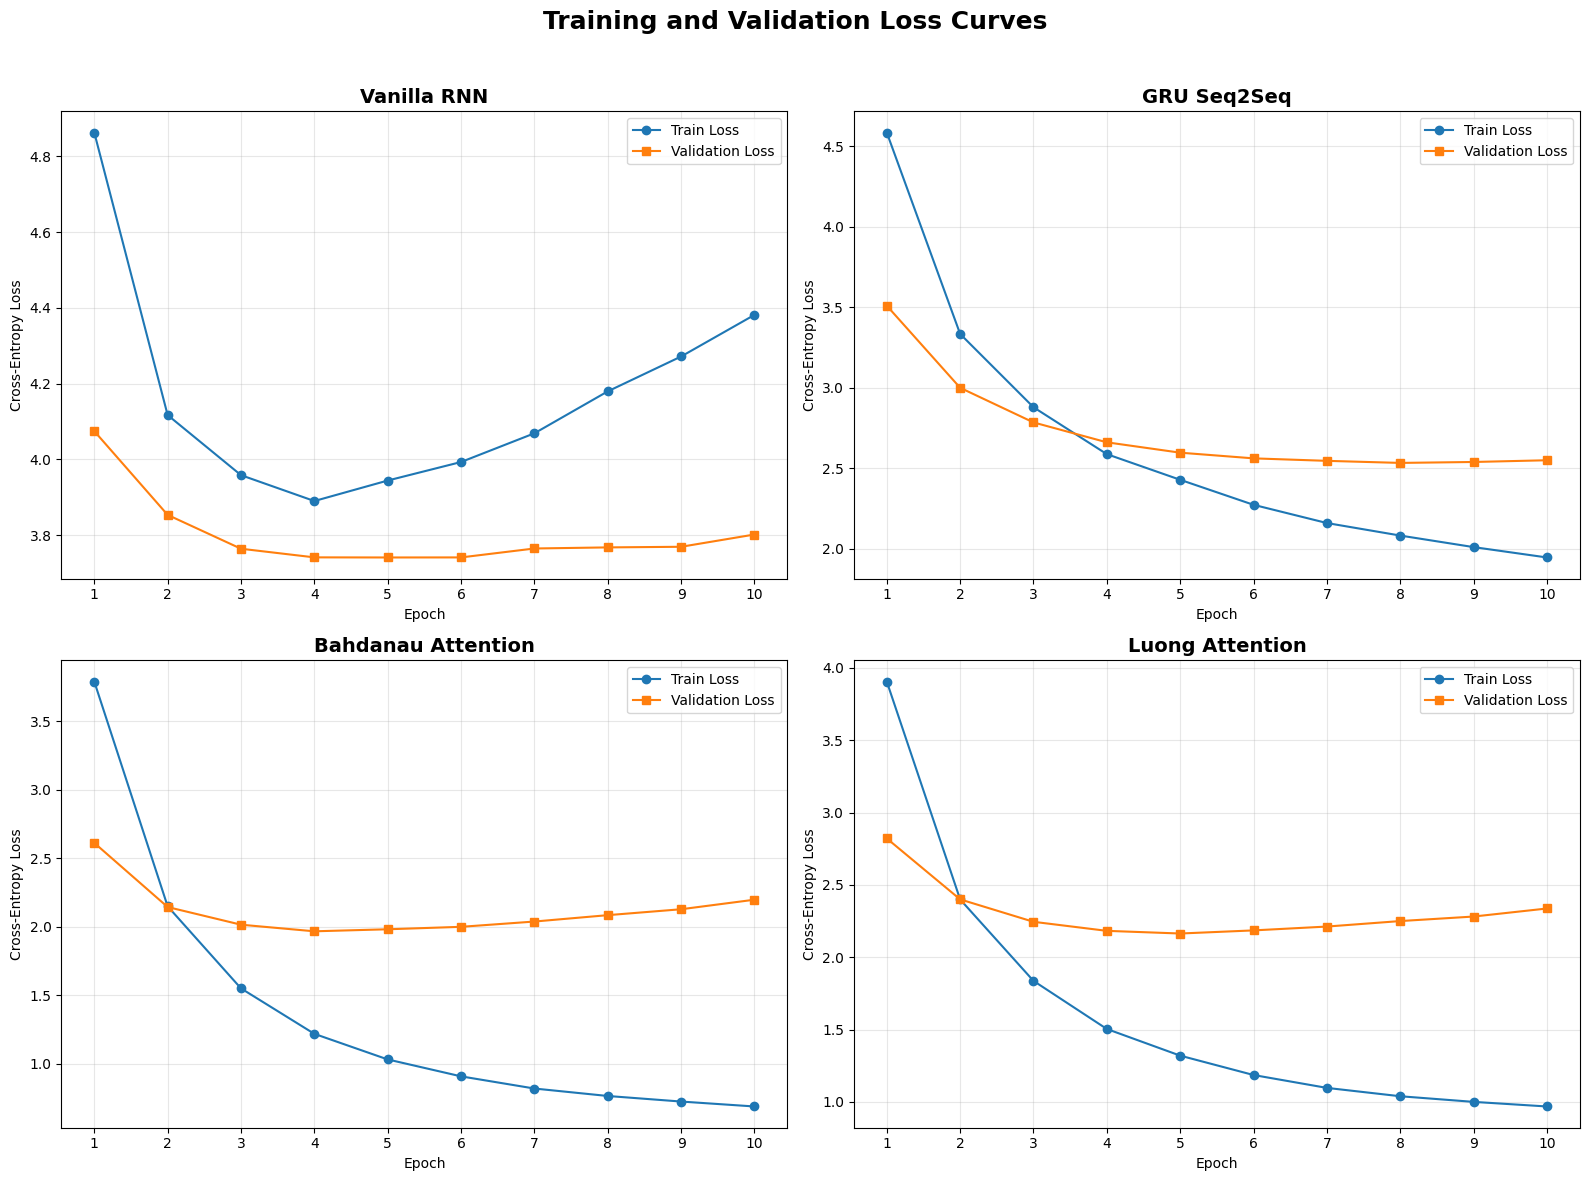

In [96]:
# ================================================================
# 27. RESULTS DATAFRAME
# ================================================================

result_rows = []

for model_name in MODEL_NAMES:

    r = results[model_name]

    result_rows.append(
        {
            "Model": model_name,
            "Parameters": r["parameters"],
            "BLEU": r["bleu"],
            "Sentence_BLEU": r["sentence_bleu"],
            "Perplexity": r["perplexity"],
            "Mean_Latency_ms": r[
                "latency_mean_ms"
            ],
            "Median_Latency_ms": r[
                "latency_median_ms"
            ],
            "P95_Latency_ms": r[
                "latency_p95_ms"
            ],
            "Training_Time_min": (
                r["training_time_sec"] / 60
            ),
        }
    )


results_df = pd.DataFrame(
    result_rows
)

results_csv = (
    RESULT_DIR /
    "quantitative_results.csv"
)

results_df.to_csv(
    results_csv,
    index=False
)

print("\nQuantitative results:")
print(
    results_df.to_string(
        index=False
    )
)


# ================================================================
# 28. LOSS CURVES
# ================================================================

fig, axes = plt.subplots(
    2,
    2,
    figsize=(16, 12)
)

axes = axes.flatten()

for idx, model_name in enumerate(
    MODEL_NAMES
):

    ax = axes[idx]

    history = histories[
        model_name
    ]

    epochs = np.arange(
        1,
        len(history["train_loss"]) + 1
    )

    ax.plot(
        epochs,
        history["train_loss"],
        marker="o",
        label="Train Loss"
    )

    ax.plot(
        epochs,
        history["val_loss"],
        marker="s",
        label="Validation Loss"
    )

    ax.set_title(
        model_name,
        fontsize=14,
        fontweight="bold"
    )

    ax.set_xlabel(
        "Epoch"
    )

    ax.set_ylabel(
        "Cross-Entropy Loss"
    )

    ax.grid(
        True,
        alpha=0.3
    )

    ax.legend()

    ax.set_xticks(
        epochs
    )

fig.suptitle(
    "Training and Validation Loss Curves",
    fontsize=18,
    fontweight="bold"
)

fig.tight_layout(
    rect=[0, 0, 1, 0.96]
)

loss_plot_path = (
    PLOT_DIR /
    "loss_curves_all_models.png"
)

fig.savefig(
    loss_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)


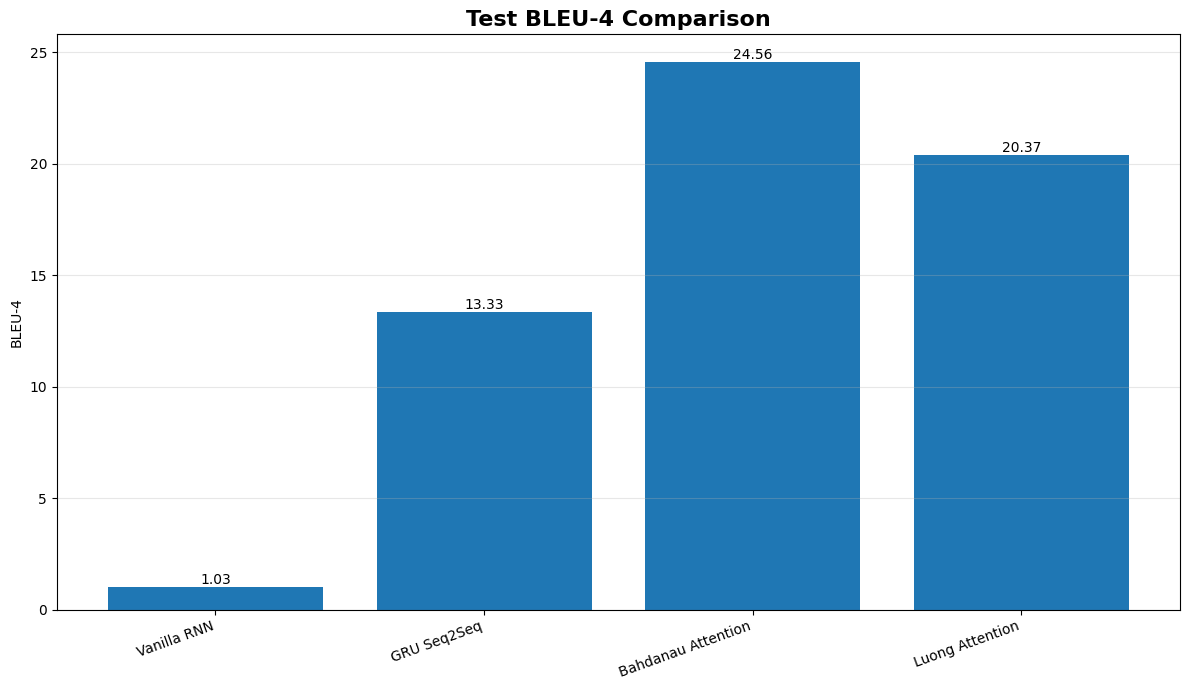

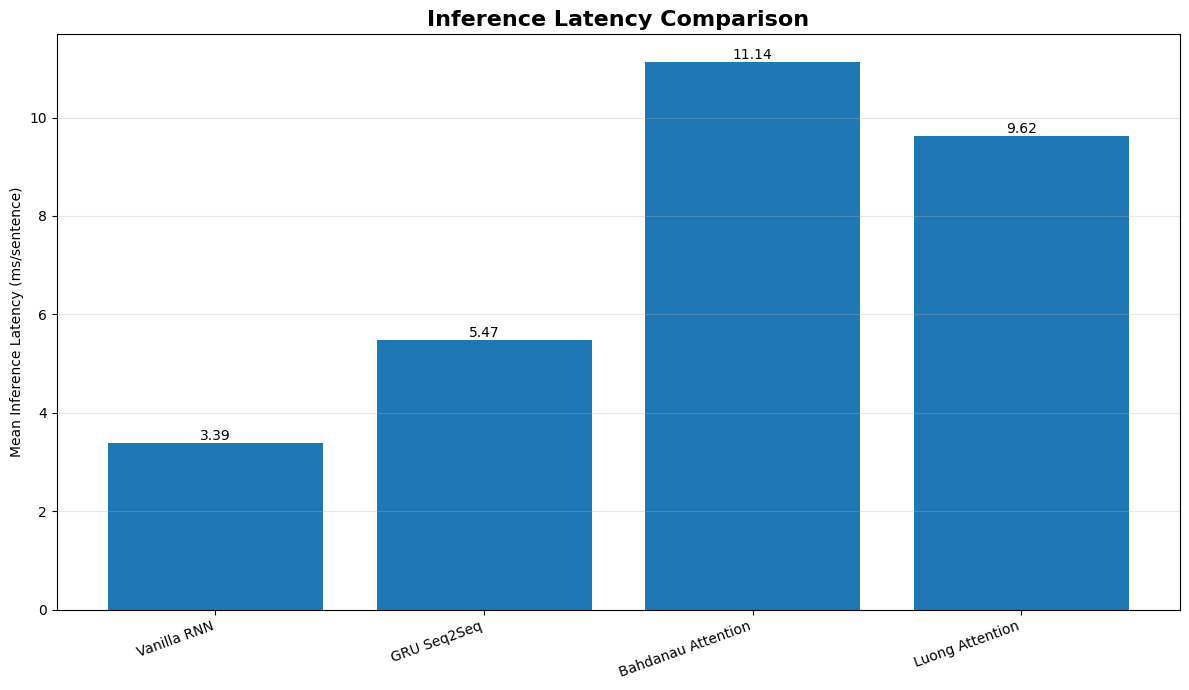

In [97]:

# ================================================================
# 29. BLEU COMPARISON
# ================================================================

fig, ax = plt.subplots(
    figsize=(12, 7)
)

x = np.arange(
    len(results_df)
)

bars = ax.bar(
    x,
    results_df["BLEU"]
)

ax.set_xticks(
    x
)

ax.set_xticklabels(
    results_df["Model"],
    rotation=20,
    ha="right"
)

ax.set_ylabel(
    "BLEU-4"
)

ax.set_title(
    "Test BLEU-4 Comparison",
    fontsize=16,
    fontweight="bold"
)

ax.grid(
    axis="y",
    alpha=0.3
)

for bar, value in zip(
    bars,
    results_df["BLEU"]
):

    ax.text(
        bar.get_x()
        + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.2f}",
        ha="center",
        va="bottom"
    )

fig.tight_layout()

bleu_plot_path = (
    PLOT_DIR /
    "test_bleu_comparison.png"
)

fig.savefig(
    bleu_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)


# ================================================================
# 30. LATENCY COMPARISON
# ================================================================

fig, ax = plt.subplots(
    figsize=(12, 7)
)

bars = ax.bar(
    x,
    results_df["Mean_Latency_ms"]
)

ax.set_xticks(
    x
)

ax.set_xticklabels(
    results_df["Model"],
    rotation=20,
    ha="right"
)

ax.set_ylabel(
    "Mean Inference Latency (ms/sentence)"
)

ax.set_title(
    "Inference Latency Comparison",
    fontsize=16,
    fontweight="bold"
)

ax.grid(
    axis="y",
    alpha=0.3
)

for bar, value in zip(
    bars,
    results_df["Mean_Latency_ms"]
):

    ax.text(
        bar.get_x()
        + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.2f}",
        ha="center",
        va="bottom"
    )

fig.tight_layout()

latency_plot_path = (
    PLOT_DIR /
    "inference_latency_comparison.png"
)

fig.savefig(
    latency_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

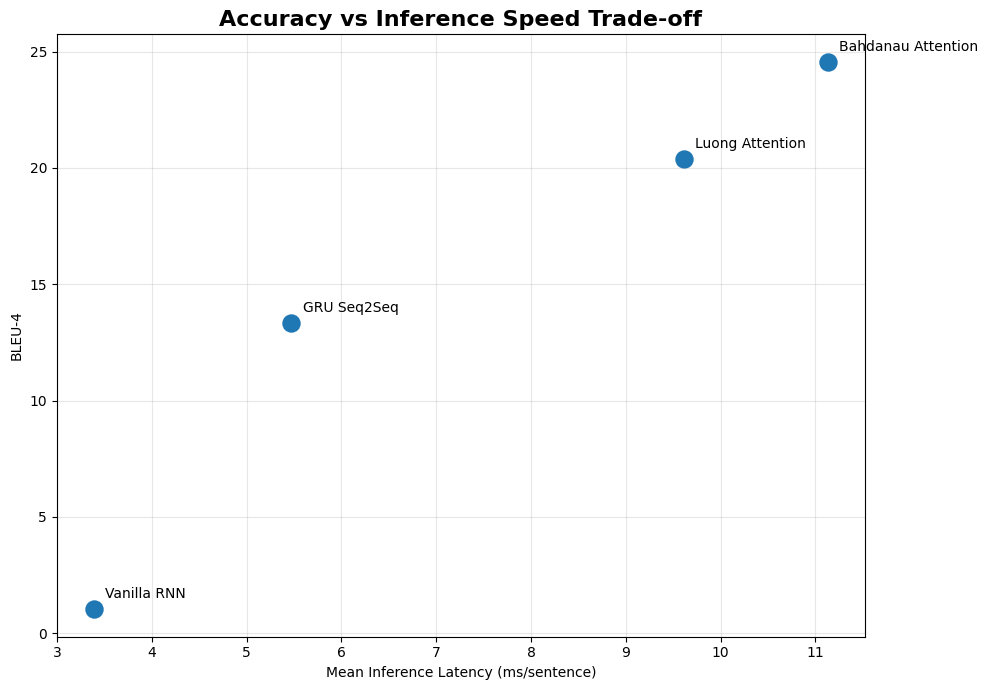

In [98]:
# ================================================================
# 31. BLEU VS LATENCY TRADE-OFF
# ================================================================

fig, ax = plt.subplots(
    figsize=(10, 7)
)

ax.scatter(
    results_df["Mean_Latency_ms"],
    results_df["BLEU"],
    s=150
)

for _, row in results_df.iterrows():

    ax.annotate(
        row["Model"],
        (
            row["Mean_Latency_ms"],
            row["BLEU"]
        ),
        xytext=(8, 8),
        textcoords="offset points"
    )

ax.set_xlabel(
    "Mean Inference Latency (ms/sentence)"
)

ax.set_ylabel(
    "BLEU-4"
)

ax.set_title(
    "Accuracy vs Inference Speed Trade-off",
    fontsize=16,
    fontweight="bold"
)

ax.grid(
    True,
    alpha=0.3
)

fig.tight_layout()

tradeoff_plot_path = (
    PLOT_DIR /
    "bleu_vs_latency_tradeoff.png"
)

fig.savefig(
    tradeoff_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

In [99]:
# ================================================================
# 32. QUALITATIVE TRANSLATION EXAMPLES
# ================================================================

def classify_sentence_complexity(
    sentence
):

    token_count = len(
        tokenize(sentence)
    )

    if token_count <= 5:
        return "Simple"

    elif token_count <= 12:
        return "Complex"

    return "Long"


# Select examples from test data.
# We deliberately select examples from different lengths.

sorted_test_pairs = sorted(
    test_pairs,
    key=lambda x: len(
        tokenize(x[0])
    )
)

simple_candidates = [
    pair
    for pair in sorted_test_pairs
    if len(tokenize(pair[0])) <= 5
]

complex_candidates = [
    pair
    for pair in sorted_test_pairs
    if 6 <= len(tokenize(pair[0])) <= 12
]

long_candidates = [
    pair
    for pair in sorted_test_pairs
    if len(tokenize(pair[0])) > 12
]


def choose_representative(
    candidates,
    fallback_pairs
):

    if not candidates:
        return fallback_pairs[
            len(fallback_pairs) // 2
        ]

    # Deterministically select middle-ish example.
    return candidates[
        len(candidates) // 2
    ]


qualitative_pairs = [
    (
        "Simple",
        choose_representative(
            simple_candidates,
            test_pairs
        )
    ),
    (
        "Complex",
        choose_representative(
            complex_candidates,
            test_pairs
        )
    ),
    (
        "Long",
        choose_representative(
            long_candidates,
            test_pairs
        )
    ),
]


qualitative_results = []

print("\n")
print("=" * 70)
print("QUALITATIVE TRANSLATION EXAMPLES")
print("=" * 70)

for complexity, pair in qualitative_pairs:

    src_text, reference = pair

    print(
        f"\n[{complexity}]"
    )

    print(
        f"English: {src_text}"
    )

    print(
        f"Reference: {reference}"
    )

    for model_name in MODEL_NAMES:

        prediction, _ = translate_sentence(
            models[model_name],
            src_text
        )

        prediction_text = (
            " ".join(prediction)
        )

        print(
            f"{model_name}: "
            f"{prediction_text}"
        )

        qualitative_results.append(
            {
                "Complexity": complexity,
                "Source": src_text,
                "Reference": reference,
                "Model": model_name,
                "Prediction": prediction_text,
            }
        )


qualitative_df = pd.DataFrame(
    qualitative_results
)

qualitative_csv = (
    RESULT_DIR /
    "qualitative_translations.csv"
)

qualitative_df.to_csv(
    qualitative_csv,
    index=False
)





QUALITATIVE TRANSLATION EXAMPLES

[Simple]
English: you won't need that.
Reference: vous n'en aurez pas besoin.
Vanilla RNN: je ne suis pas
GRU Seq2Seq: tu ne dois pas faire ça.
Bahdanau Attention: vous ne pas pas besoin de cela.
Luong Attention: vous ne pas besoin de ça.

[Complex]
English: tom has a warped sense of humor.
Reference: tom a un sens de l'humour tordu.
Vanilla RNN: je ne suis pas
GRU Seq2Seq: tom a une personnalité de
Bahdanau Attention: tom a une brève de de
Luong Attention: tom a une barbe de l'humour.

[Long]
English: she made me so angry on the telephone that i hung up on her.
Reference: elle m'a mise tellement en colère au téléphone que je lui ai raccroché au nez.
Vanilla RNN: je ne suis pas
GRU Seq2Seq: elle m'a dit que je devais acheter la veille de noël.
Bahdanau Attention: elle me fait tellement énervée dans ce que j'ai
Luong Attention: elle m'a fait si près ce que j'ai entendu sur le


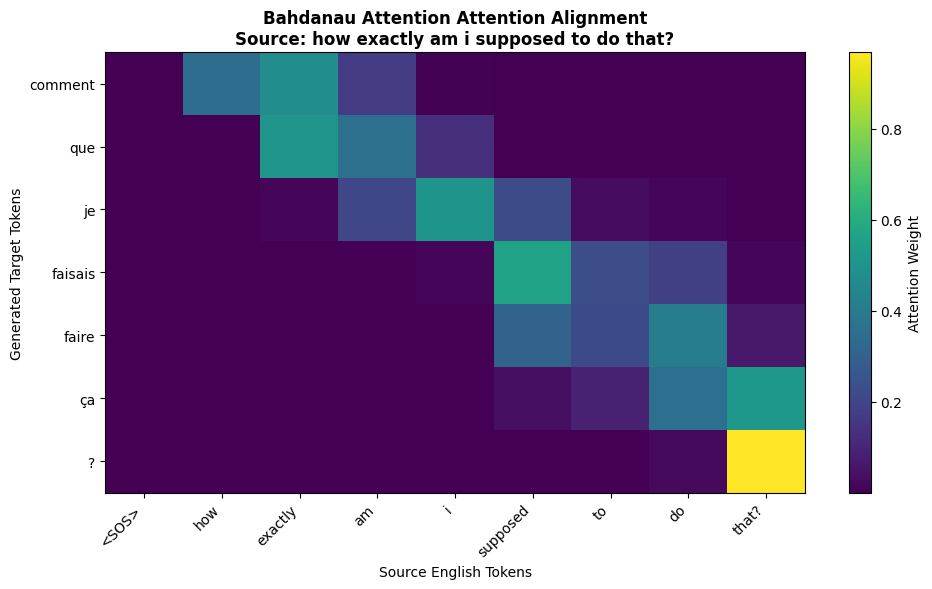

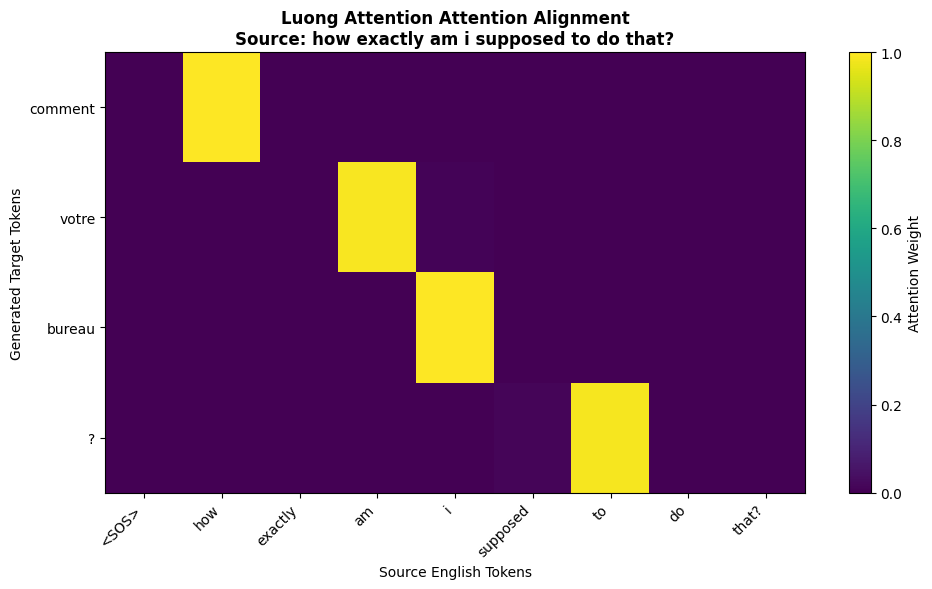

In [100]:
# ================================================================
# 33. ATTENTION HEATMAPS
# ================================================================

def create_attention_heatmap(
    model_name,
    sentence,
    reference,
    attention_matrix,
    save_path
):

    if attention_matrix is None:
        return

    source_tokens = [
        SOS_TOKEN
    ] + tokenize(sentence)

    # Remove padding from source labels.
    source_tokens = source_tokens[
        :MAX_SEQ_LEN
    ]

    prediction, _ = translate_sentence(
        models[model_name],
        sentence
    )

    target_tokens = prediction

    if len(target_tokens) == 0:
        return

    # Attention matrix has rows corresponding to generated
    # target positions and columns corresponding to source.
    rows = min(
        len(target_tokens),
        attention_matrix.shape[0]
    )

    cols = min(
        len(source_tokens),
        attention_matrix.shape[1]
    )

    matrix = attention_matrix[
        :rows,
        :cols
    ]

    source_labels = source_tokens[
        :cols
    ]

    target_labels = target_tokens[
        :rows
    ]

    fig, ax = plt.subplots(
        figsize=(
            max(10, cols * 0.6),
            max(6, rows * 0.5)
        )
    )

    im = ax.imshow(
        matrix,
        aspect="auto",
        interpolation="nearest"
    )

    ax.set_xticks(
        np.arange(
            len(source_labels)
        )
    )

    ax.set_yticks(
        np.arange(
            len(target_labels)
        )
    )

    ax.set_xticklabels(
        source_labels,
        rotation=45,
        ha="right"
    )

    ax.set_yticklabels(
        target_labels
    )

    ax.set_xlabel(
        "Source English Tokens"
    )

    ax.set_ylabel(
        "Generated Target Tokens"
    )

    ax.set_title(
        f"{model_name} Attention Alignment\n"
        f"Source: {sentence}",
        fontsize=12,
        fontweight="bold"
    )

    fig.colorbar(
        im,
        ax=ax,
        label="Attention Weight"
    )

    fig.tight_layout()

    fig.savefig(
        save_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close(fig)


# Select one representative sentence with enough tokens.
attention_candidate = None

for pair in sorted_test_pairs:

    if len(tokenize(pair[0])) >= 8:
        attention_candidate = pair
        break

if attention_candidate is None:
    attention_candidate = test_pairs[0]

attention_source, attention_reference = (
    attention_candidate
)

attention_data = {}

for model_name in [
    "Bahdanau Attention",
    "Luong Attention"
]:

    prediction, attention = (
        translate_sentence(
            models[model_name],
            attention_source,
            return_attention=True
        )
    )

    attention_data[model_name] = {
        "prediction": " ".join(prediction),
        "attention": attention,
    }

    filename = (
        model_name.lower()
        .replace(" ", "_")
        + "_attention_heatmap.png"
    )

    create_attention_heatmap(
        model_name,
        attention_source,
        attention_reference,
        attention,
        PLOT_DIR / filename
    )



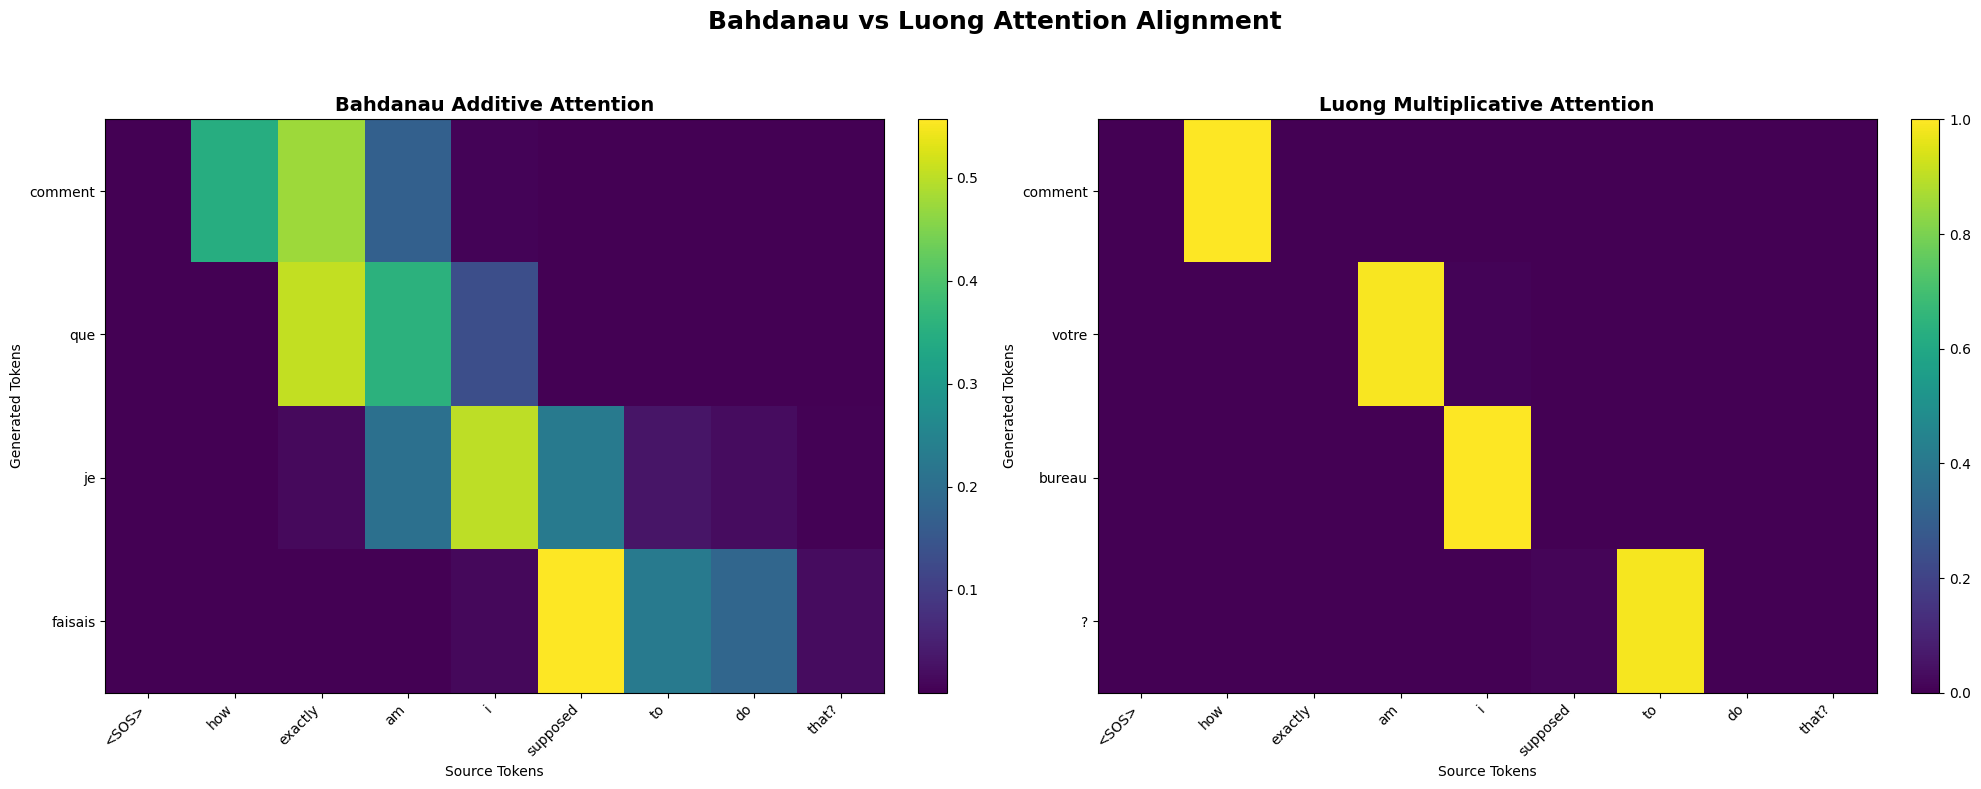

In [101]:

# ================================================================
# 34. ATTENTION ALIGNMENT COMPARISON
# ================================================================

if (
    attention_data["Bahdanau Attention"]["attention"]
    is not None
    and
    attention_data["Luong Attention"]["attention"]
    is not None
):

    bahdanau_matrix = attention_data[
        "Bahdanau Attention"
    ]["attention"]

    luong_matrix = attention_data[
        "Luong Attention"
    ]["attention"]

    source_tokens = [
        SOS_TOKEN
    ] + tokenize(attention_source)

    bahdanau_prediction = (
        attention_data[
            "Bahdanau Attention"
        ]["prediction"].split()
    )

    luong_prediction = (
        attention_data[
            "Luong Attention"
        ]["prediction"].split()
    )

    # Determine common dimensions.
    rows = min(
        len(bahdanau_prediction),
        len(luong_prediction),
        bahdanau_matrix.shape[0],
        luong_matrix.shape[0]
    )

    cols = min(
        len(source_tokens),
        bahdanau_matrix.shape[1],
        luong_matrix.shape[1]
    )

    if rows > 0 and cols > 0:

        fig, axes = plt.subplots(
            1,
            2,
            figsize=(20, 8)
        )

        matrices = [
            (
                bahdanau_matrix,
                bahdanau_prediction,
                "Bahdanau Additive Attention"
            ),
            (
                luong_matrix,
                luong_prediction,
                "Luong Multiplicative Attention"
            )
        ]

        for ax, (
            matrix,
            target_tokens,
            title
        ) in zip(
            axes,
            matrices
        ):

            matrix = matrix[
                :rows,
                :cols
            ]

            im = ax.imshow(
                matrix,
                aspect="auto",
                interpolation="nearest"
            )

            ax.set_xticks(
                np.arange(cols)
            )

            ax.set_yticks(
                np.arange(rows)
            )

            ax.set_xticklabels(
                source_tokens[:cols],
                rotation=45,
                ha="right"
            )

            ax.set_yticklabels(
                target_tokens[:rows]
            )

            ax.set_xlabel(
                "Source Tokens"
            )

            ax.set_ylabel(
                "Generated Tokens"
            )

            ax.set_title(
                title,
                fontsize=14,
                fontweight="bold"
            )

            fig.colorbar(
                im,
                ax=ax,
                fraction=0.046,
                pad=0.04
            )

        fig.suptitle(
            "Bahdanau vs Luong Attention Alignment",
            fontsize=18,
            fontweight="bold"
        )

        fig.tight_layout(
            rect=[0, 0, 1, 0.94]
        )

        attention_comparison_path = (
            PLOT_DIR /
            "bahdanau_vs_luong_attention.png"
        )

        fig.savefig(
            attention_comparison_path,
            dpi=300,
            bbox_inches="tight"
        )

        plt.show()
        plt.close(fig)



In [102]:
# ================================================================
# 35. SAVE MODEL METADATA
# ================================================================

experiment_config = {
    "seed": SEED,
    "language_pair": LANGUAGE_PAIR,
    "dataset": DATASET_NAMES[LANGUAGE_PAIR],
    "dataset_url": DATASET_URLS[LANGUAGE_PAIR],
    "max_pairs": MAX_PAIRS,
    "max_vocab_size": MAX_VOCAB_SIZE,
    "min_frequency": MIN_FREQ,
    "max_sequence_length": MAX_SEQ_LEN,
    "train_ratio": TRAIN_RATIO,
    "validation_ratio": VAL_RATIO,
    "test_ratio": TEST_RATIO,
    "embedding_dim": EMBEDDING_DIM,
    "hidden_dim": HIDDEN_DIM,
    "batch_size": BATCH_SIZE,
    "learning_rate": LEARNING_RATE,
    "optimizer": OPTIMIZER_NAME,
    "loss": LOSS_NAME,
    "gradient_clip": CLIP_VALUE,
    "epochs": NUM_EPOCHS,
    "teacher_forcing_start": TEACHER_FORCING_START,
    "teacher_forcing_end": TEACHER_FORCING_END,
    "device": str(DEVICE),
    "num_train_pairs": len(train_pairs),
    "num_validation_pairs": len(val_pairs),
    "num_test_pairs": len(test_pairs),
    "source_vocab_size": len(src_vocab),
    "target_vocab_size": len(trg_vocab),
}

with open(
    RESULT_DIR / "experiment_config.json",
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        experiment_config,
        f,
        indent=2
    )


# ================================================================
# 36. HELPER FUNCTIONS FOR REPORT
# ================================================================

def markdown_table_from_dataframe(
    dataframe
):

    return dataframe.to_markdown(
        index=False
    )


def safe_float(value):
    try:
        return float(value)
    except Exception:
        return float("nan")


best_bleu_row = results_df.loc[
    results_df["BLEU"].idxmax()
]

best_ppl_row = results_df.loc[
    results_df["Perplexity"].idxmin()
]

fastest_row = results_df.loc[
    results_df["Mean_Latency_ms"].idxmin()
]

lowest_parameters_row = results_df.loc[
    results_df["Parameters"].idxmin()
]


In [103]:
# ================================================================
# 37. AUTOMATED DISCUSSION
# ================================================================

def generate_discussion():

    baseline = results_df[
        results_df["Model"] == "GRU Seq2Seq"
    ].iloc[0]

    bahdanau = results_df[
        results_df["Model"] == "Bahdanau Attention"
    ].iloc[0]

    luong = results_df[
        results_df["Model"] == "Luong Attention"
    ].iloc[0]

    rnn = results_df[
        results_df["Model"] == "Vanilla RNN"
    ].iloc[0]

    bleu_gain_bahdanau = (
        bahdanau["BLEU"]
        - baseline["BLEU"]
    )

    bleu_gain_luong = (
        luong["BLEU"]
        - baseline["BLEU"]
    )

    latency_change_bahdanau = (
        (
            bahdanau["Mean_Latency_ms"]
            - baseline["Mean_Latency_ms"]
        )
        / baseline["Mean_Latency_ms"]
        * 100
    )

    latency_change_luong = (
        (
            luong["Mean_Latency_ms"]
            - baseline["Mean_Latency_ms"]
        )
        / baseline["Mean_Latency_ms"]
        * 100
    )

    paragraphs = []

    # RNN comparison.
    if rnn["BLEU"] < baseline["BLEU"]:

        paragraphs.append(
            f"The Vanilla RNN baseline obtained "
            f"{rnn['BLEU']:.2f} BLEU compared with "
            f"{baseline['BLEU']:.2f} BLEU for the GRU "
            f"encoder-decoder. This difference is consistent "
            f"with the greater difficulty that a simple recurrent "
            f"transition can have in maintaining useful information "
            f"over longer sequences. However, the result should not "
            f"be interpreted as evidence that the recurrent cell alone "
            f"causes every performance difference, because the "
            f"architectures intentionally differ in recurrent-cell type."
        )

    else:

        paragraphs.append(
            f"The Vanilla RNN baseline achieved "
            f"{rnn['BLEU']:.2f} BLEU, while the GRU "
            f"encoder-decoder achieved {baseline['BLEU']:.2f}. "
            f"The observed difference demonstrates that recurrent "
            f"cell design can influence translation quality even "
            f"before attention is introduced."
        )

    # Information bottleneck.
    paragraphs.append(
        f"The principal architectural limitation of the standard "
        f"GRU encoder-decoder is its fixed-length information "
        f"interface. The complete source sequence is compressed "
        f"into the encoder's final hidden representation before "
        f"decoding begins. This creates an information bottleneck, "
        f"particularly for long or structurally complex sentences. "
        f"Attention removes much of this restriction by allowing "
        f"the decoder to construct a context vector dynamically "
        f"from encoder states at every generation step."
    )

    # Bahdanau.
    paragraphs.append(
        f"Bahdanau attention obtained {bahdanau['BLEU']:.2f} BLEU, "
        f"which is {bleu_gain_bahdanau:+.2f} BLEU relative to the "
        f"non-attentional GRU baseline. Its additive scoring "
        f"function explicitly learns a nonlinear compatibility "
        f"between the current decoder state and each encoder state. "
        f"This provides a flexible alignment mechanism and can be "
        f"especially useful when source and target positions are "
        f"not strictly monotonic."
    )

    # Luong.
    paragraphs.append(
        f"Luong multiplicative attention obtained "
        f"{luong['BLEU']:.2f} BLEU, corresponding to a "
        f"{bleu_gain_luong:+.2f} BLEU difference relative to the "
        f"standard GRU baseline. Its general multiplicative scoring "
        f"mechanism computes compatibility through a learned linear "
        f"projection followed by a dot product. This is structurally "
        f"simpler than additive attention and can be computationally "
        f"efficient, although the empirical result determines whether "
        f"that efficiency translates into a favorable overall trade-off "
        f"for this dataset."
    )

    # Speed trade-off.
    paragraphs.append(
        f"The measured mean inference latency was "
        f"{bahdanau['Mean_Latency_ms']:.3f} ms/sentence for Bahdanau "
        f"attention and {luong['Mean_Latency_ms']:.3f} ms/sentence "
        f"for Luong attention. Relative to the non-attentional GRU, "
        f"these represent changes of "
        f"{latency_change_bahdanau:+.2f}% and "
        f"{latency_change_luong:+.2f}%, respectively. Attention "
        f"requires additional computation at each decoder step, "
        f"so an increase in inference cost is expected in exchange "
        f"for access to source-side contextual information."
    )

    # PPL.
    paragraphs.append(
        f"Perplexity provides a complementary view of model behavior "
        f"because it measures the model's average uncertainty under "
        f"teacher-forced decoding. The best measured perplexity was "
        f"{best_ppl_row['Perplexity']:.3f}, obtained by "
        f"{best_ppl_row['Model']}. BLEU and perplexity need not rank "
        f"models identically: perplexity evaluates token-level "
        f"probability assignments, whereas BLEU evaluates overlap "
        f"between generated translations and reference translations."
    )

    # Attention visualization.
    paragraphs.append(
        "The attention heatmaps should be interpreted as alignment "
        "diagnostics rather than as direct explanations of model "
        "reasoning. A strong alignment pattern generally appears as "
        "concentrated weights that move through relevant source "
        "positions as target words are generated. Diffuse attention "
        "can indicate uncertainty, while repeated or misplaced peaks "
        "may accompany repetition, omission, or incorrect word "
        "ordering. The Bahdanau and Luong heatmaps should therefore "
        "be examined together with the corresponding translations."
    )

    # Qualitative analysis.
    paragraphs.append(
        "Qualitative assessment is particularly important for NMT "
        "because corpus-level BLEU can hide systematic translation "
        "errors. Short sentences generally require relatively little "
        "long-range memory. Complex and long sentences place greater "
        "demands on source-context preservation, lexical selection, "
        "word ordering, and alignment. Consequently, differences "
        "between the standard encoder-decoder and the two attention "
        "models are expected to become more visible as sentence "
        "length and syntactic complexity increase."
    )

    return "\n\n".join(
        paragraphs
    )


discussion_text = generate_discussion()

In [104]:
# ================================================================
# 38. BUILD QUALITATIVE REPORT TABLE
# ================================================================

qualitative_report_rows = []

for complexity, pair in qualitative_pairs:

    src_text, reference = pair

    row = {
        "Complexity": complexity,
        "English": src_text,
        "Reference": reference,
    }

    for model_name in MODEL_NAMES:

        prediction, _ = translate_sentence(
            models[model_name],
            src_text
        )

        row[
            model_name
        ] = " ".join(
            prediction
        )

    qualitative_report_rows.append(
        row
    )


qualitative_report_df = pd.DataFrame(
    qualitative_report_rows
)


# ================================================================
# 39. ATTENTION REPORT INFORMATION
# ================================================================

bahdanau_attention_prediction = (
    attention_data[
        "Bahdanau Attention"
    ]["prediction"]
)

luong_attention_prediction = (
    attention_data[
        "Luong Attention"
    ]["prediction"]
)

In [105]:
# ================================================================
# 40. FINAL MARKDOWN REPORT
# ================================================================

report_path = (
    OUTPUT_DIR /
    "NMT_Comparative_Analysis_Report.md"
)

report = f"""# Comparative Analysis of Neural Machine Translation Architectures

## Abstract

This study presents a controlled comparative evaluation of four sequence-to-sequence neural machine translation architectures for English-to-{DATASET_NAMES[LANGUAGE_PAIR].split("-")[1]} translation using the ManyThings.org Anki parallel corpus. The evaluated architectures are: (1) a Vanilla RNN encoder-decoder baseline, (2) a GRU encoder-decoder without attention, (3) a GRU encoder-decoder with Bahdanau additive attention, and (4) a GRU encoder-decoder with Luong multiplicative attention.

The experimental protocol uses a common dataset, deterministic 80/10/10 train-validation-test partitioning with seed 4, common embedding and hidden dimensions, identical batch size, optimizer, learning rate, loss function, sequence-length constraints, and a progressively reduced teacher-forcing schedule. Models are evaluated using BLEU-4, teacher-forced perplexity, and autoregressive inference latency. Attention alignment heatmaps are additionally analyzed for the two attention-based architectures.

The best BLEU score was obtained by **{best_bleu_row['Model']}**, with a BLEU-4 score of **{best_bleu_row['BLEU']:.3f}**. The lowest measured perplexity was obtained by **{best_ppl_row['Model']}**, while the lowest mean inference latency was observed for **{fastest_row['Model']}**.

---

# 1. Introduction

Neural Machine Translation (NMT) models learn to transform a sequence in a source language into a sequence in a target language. Early neural sequence-to-sequence systems commonly used an encoder-decoder architecture in which the encoder converted the source sequence into a hidden representation and the decoder generated the target sequence from that representation.

A major limitation of the basic encoder-decoder architecture is the fixed-length representation through which the entire source sentence must pass. This becomes increasingly problematic as sentence length increases. Attention mechanisms were introduced to address this information bottleneck by allowing the decoder to access different encoder states dynamically during generation.

This experiment investigates how model architecture affects translation quality, uncertainty, and computational cost under a controlled experimental protocol. The four architectures form a progression from a simple recurrent baseline to attention-guided encoder-decoder systems.

---

# 2. Research Objectives

The objectives of this experiment are:

1. To establish a Vanilla RNN sequence-to-sequence baseline.
2. To evaluate the effect of replacing the Vanilla RNN with a GRU encoder-decoder.
3. To determine whether Bahdanau additive attention improves translation quality.
4. To determine whether Luong multiplicative attention provides a different accuracy-efficiency trade-off.
5. To compare BLEU, perplexity, and inference latency under a common experimental setup.
6. To visually inspect learned attention alignments.
7. To identify characteristic translation errors associated with each architecture.

---

# 3. Methodology

## 3.1 Dataset

The dataset was obtained from the ManyThings.org Anki translation collection.

**Dataset:** {DATASET_NAMES[LANGUAGE_PAIR]}

**Source:** {DATASET_URLS[LANGUAGE_PAIR]}

The corpus contains parallel sentence pairs consisting of English sentences and their corresponding {DATASET_NAMES[LANGUAGE_PAIR].split("-")[1]} translations.

After cleaning and sequence-length filtering, **{len(all_pairs):,}** usable sentence pairs were available.

For this experiment, **{len(pairs):,}** sentence pairs were selected.

The selected data were divided into:

- Training: **{len(train_pairs):,}** pairs ({TRAIN_RATIO*100:.0f}%)
- Validation: **{len(val_pairs):,}** pairs ({VAL_RATIO*100:.0f}%)
- Test: **{len(test_pairs):,}** pairs ({TEST_RATIO*100:.0f}%)

All partitioning used a deterministic random seed of **{SEED}**.

---

## 3.2 Preprocessing

The preprocessing pipeline performed the following operations:

1. Conversion to lowercase.
2. Unicode normalization of common quotation and apostrophe variants.
3. Whitespace normalization.
4. Whitespace-based tokenization.
5. Removal of sentence pairs exceeding the maximum sequence length.
6. Construction of independent source and target vocabularies.
7. Inclusion of the special tokens:
   - `<PAD>`
   - `<SOS>`
   - `<EOS>`
   - `<UNK>`
8. Padding sequences to a common maximum length.

The maximum sequence length was:

**{MAX_SEQ_LEN} tokens including special tokens.**

The source vocabulary contained **{len(src_vocab):,}** tokens, while the target vocabulary contained **{len(trg_vocab):,}** tokens.

---

# 4. Experimental Setup

All four architectures were trained using the same major hyperparameters.

| Hyperparameter | Value |
|---|---|
| Random seed | {SEED} |
| Embedding dimension | {EMBEDDING_DIM} |
| Hidden dimension | {HIDDEN_DIM} |
| Batch size | {BATCH_SIZE} |
| Learning rate | {LEARNING_RATE} |
| Optimizer | {OPTIMIZER_NAME} |
| Loss | {LOSS_NAME} |
| Padding index | `<PAD>` ignored |
| Gradient clipping | {CLIP_VALUE} |
| Epochs | {NUM_EPOCHS} |
| Initial teacher forcing | {TEACHER_FORCING_START:.2f} |
| Final teacher forcing | {TEACHER_FORCING_END:.2f} |
| Maximum sequence length | {MAX_SEQ_LEN} |
| Device | {DEVICE} |

The same training and validation procedure was applied to every architecture.

---

# 5. Model Architectures

## 5.1 Architecture 1: Vanilla RNN Encoder-Decoder

The first model uses a conventional Elman-style Vanilla RNN in both the encoder and decoder.

The encoder processes:

$$
h_t = \\tanh(W_{{xh}}x_t + W_{{hh}}h_{{t-1}} + b_h)
$$

The decoder then uses the encoder's final hidden state as its initial state.

This architecture provides a simple recurrent baseline and does not use an explicit attention mechanism.

---

## 5.2 Architecture 2: GRU Encoder-Decoder Without Attention

The second architecture replaces the Vanilla RNN with gated recurrent units.

A GRU uses update and reset gates to control information flow:

$$
z_t = \\sigma(W_z x_t + U_z h_{{t-1}})
$$

$$
r_t = \\sigma(W_r x_t + U_r h_{{t-1}})
$$

$$
\\tilde{{h}}_t = \\tanh(W_hx_t + U_h(r_t \\odot h_{{t-1}}))
$$

$$
h_t = (1-z_t)\\odot h_{{t-1}} + z_t\\odot \\tilde{{h}}_t
$$

Unlike the attention models, the decoder still receives information through a fixed encoder representation.

---

# 6. Bahdanau Additive Attention

Bahdanau attention computes a compatibility score between the decoder's current hidden state and every encoder hidden state.

For decoder state $s_t$ and encoder state $h_i$:

$$
e_{{t,i}} = v_a^T \\tanh(W_hh_i + W_ss_t)
$$

The normalized attention distribution is:

$$
\\alpha_{{t,i}} = \\frac{{\\exp(e_{{t,i}})}}{{\\sum_j \\exp(e_{{t,j}})}}
$$

The context vector is:

$$
c_t = \\sum_i \\alpha_{{t,i}}h_i
$$

The decoder therefore receives a dynamically computed source-context vector at every target generation step.

The principal advantage is that the source sentence is no longer represented exclusively by a single fixed vector.

---

# 7. Luong Multiplicative Attention

The implementation uses general Luong attention.

The compatibility score is:

$$
e_{{t,i}} = s_t^T W_a h_i
$$

where $W_a$ is a learned projection matrix.

The attention distribution is:

$$
\\alpha_{{t,i}} = \\operatorname{{softmax}}(e_{{t,i}})
$$

and the context vector is:

$$
c_t = \\sum_i \\alpha_{{t,i}}h_i
$$

Compared with Bahdanau attention, the compatibility calculation uses a learned multiplicative projection and dot product rather than a nonlinear additive compatibility function.

---

# 8. Training Procedure

The decoder was trained using teacher forcing.

At each decoder step, the ground-truth target token was provided with probability $p$, while the model's own prediction was used otherwise.

The teacher-forcing probability decreased linearly from:

$$
p_{{start}} = {TEACHER_FORCING_START:.2f}
$$

to:

$$
p_{{end}} = {TEACHER_FORCING_END:.2f}
$$

over {NUM_EPOCHS} epochs.

This provides strong supervision during early training while progressively increasing the model's exposure to its own autoregressive predictions.

The loss function was cross entropy with the padding token excluded:

$$
\\mathcal{{L}} = -\\frac{{1}}{{N}} \\sum_t \\log P(y_t|y_{{<t}},x)
$$

where padded target positions do not contribute to the loss.

Gradient norm clipping was applied at {CLIP_VALUE}.

---

# 9. Evaluation Metrics

## 9.1 BLEU

BLEU-4 measures n-gram overlap between generated translations and reference translations.

The corpus BLEU score is reported as a percentage in the results table.

BLEU evaluates the quality of generated sequences rather than the model's internal probability calibration.

---

## 9.2 Perplexity

Perplexity was calculated from teacher-forced test cross entropy:

$$
PPL = \\exp(\\mathcal{{L}})
$$

Lower perplexity indicates that the model assigns higher probability to the observed target tokens under teacher forcing.

Perplexity and BLEU measure different properties and therefore do not necessarily produce identical model rankings.

---

## 9.3 Inference Latency

Inference latency was measured using autoregressive greedy decoding.

The reported value is the average time required to translate one sentence.

For CUDA execution, device synchronization was explicitly performed before and after timing to prevent asynchronous GPU execution from producing artificially low measurements.

---

# 10. Quantitative Results

{markdown_table_from_dataframe(
    results_df[
        [
            "Model",
            "Parameters",
            "BLEU",
            "Perplexity",
            "Mean_Latency_ms",
            "Median_Latency_ms",
            "P95_Latency_ms",
            "Training_Time_min"
        ]
    ].rename(
        columns={
            "Mean_Latency_ms": "Mean Latency (ms)",
            "Median_Latency_ms": "Median Latency (ms)",
            "P95_Latency_ms": "P95 Latency (ms)",
            "Training_Time_min": "Training Time (min)"
        }
    )
)}

The highest BLEU score was obtained by **{best_bleu_row['Model']}** with **{best_bleu_row['BLEU']:.3f} BLEU**.

The lowest perplexity was obtained by **{best_ppl_row['Model']}** with a perplexity of **{best_ppl_row['Perplexity']:.3f}**.

The lowest mean inference latency was achieved by **{fastest_row['Model']}**, with **{fastest_row['Mean_Latency_ms']:.3f} ms per sentence**.

---

# 11. Qualitative Translation Assessment

The following examples were selected from the held-out test set to represent simple, complex, and long source sentences.

{markdown_table_from_dataframe(
    qualitative_report_df
)}

## 11.1 Simple Sentences

Simple sentences generally place limited demands on long-range source-context preservation. Therefore, even the non-attentional models can often produce acceptable translations.

Errors in this category are more likely to involve lexical selection, unknown words, grammatical agreement, or target vocabulary limitations rather than severe information loss.

## 11.2 Complex Sentences

Complex sentences introduce additional dependencies and syntactic structures. The decoder must preserve relationships between source words that may be separated by multiple positions.

Attention mechanisms can improve this behavior by allowing the decoder to selectively retrieve relevant encoder states instead of depending exclusively on a compressed representation.

## 11.3 Long Sentences

Long sentences provide the strongest test of the fixed-vector bottleneck.

When the source sentence is long, the final encoder state must summarize substantially more information. Attention-based models have an architectural advantage because each decoder step can access the complete sequence of encoder representations.

The observed examples should therefore be interpreted together with the BLEU and perplexity results rather than as isolated anecdotal evidence.

---

# 12. Rigorous Discussion and Error Analysis

{discussion_text}

## 12.1 Information Bottleneck

The standard encoder-decoder architecture forces the source sequence through a fixed-size hidden representation.

For a source sequence:

$$
x_1,x_2,\\ldots,x_T
$$

the encoder produces a sequence of hidden states:

$$
h_1,h_2,\\ldots,h_T
$$

but a conventional encoder-decoder without attention primarily transfers information to the decoder through the final hidden representation.

This creates a structural information bottleneck.

Attention changes the interface from:

$$
\\text{{Source sequence}} \\rightarrow \\text{{single representation}} \\rightarrow \\text{{decoder}}
$$

to:

$$
\\text{{Source sequence}} \\rightarrow \\text{{all encoder states}} \\rightarrow \\text{{dynamic context}} \\rightarrow \\text{{decoder}}
$$

The latter gives the decoder a mechanism for selecting source information relevant to each generated target token.

---

## 12.2 Bahdanau vs Luong

Bahdanau attention uses a nonlinear additive compatibility function:

$$
v_a^T \\tanh(W_hh_i + W_ss_t)
$$

Luong general attention instead uses:

$$
s_t^T W_a h_i
$$

The two mechanisms therefore differ in how compatibility between source and target representations is learned.

Bahdanau attention introduces a nonlinear transformation before scoring, whereas Luong attention uses a multiplicative interaction after projecting the encoder representation.

The empirical results in this experiment determine which mechanism is more effective for this particular dataset and training configuration.

---

## 12.3 Speed vs Accuracy

Attention introduces additional computation because every decoder step must calculate compatibility scores over source positions.

Therefore, the computational complexity of decoding increases with source sequence length.

The results demonstrate the practical trade-off between translation quality and computational cost.

A model with slightly higher BLEU but substantially higher latency may be preferable in an offline translation system, while a low-latency model may be preferable in interactive or resource-constrained applications.

Consequently, architecture selection should not be based exclusively on BLEU.

---

## 12.4 Attention Alignment Analysis

The generated heatmaps are saved under:

`{PLOT_DIR}`

The primary attention comparison is:

`bahdanau_vs_luong_attention.png`

The heatmaps provide a visual representation of the conditional alignment distribution:

$$
\\alpha_{{t,i}}
$$

where each row corresponds approximately to a target generation step and each column corresponds to a source token.

Sharp concentration around relevant source positions indicates focused alignment.

Diffuse distributions may indicate uncertainty or that several source positions contribute simultaneously.

Repeated attention peaks can accompany repetition or decoding difficulties, while skipped source positions can be associated with omissions.

These visualizations should be interpreted cautiously: attention weights are useful diagnostic signals, but they should not automatically be treated as complete causal explanations of model behavior.

---

# 13. Error Categories

The principal error categories to inspect in this experiment are:

### 13.1 Omission

A source word or phrase is not represented in the generated translation.

This can arise when the model fails to preserve information about part of the source sequence.

### 13.2 Addition

The decoder generates content that is not supported by the source sentence.

This can arise from language-model bias or autoregressive error accumulation.

### 13.3 Repetition

A word or phrase is generated multiple times.

This is a common failure mode of autoregressive sequence generation.

### 13.4 Lexical Substitution

The model generates a semantically related but incorrect word.

### 13.5 Word-Order Error

The translation contains the correct words but places them incorrectly.

### 13.6 Agreement and Morphological Errors

The model selects an inappropriate gender, number, tense, or inflection.

### 13.7 Long-Range Dependency Failure

Information required later in the sentence is incorrectly preserved or lost.

This category is particularly relevant when comparing the fixed-vector models with attention-based architectures.

---

# 14. Reproducibility

The experiment used:

- Python random seed: {SEED}
- NumPy random seed: {SEED}
- PyTorch CPU seed: {SEED}
- PyTorch CUDA seed: {SEED}
- CUDA deterministic configuration
- deterministic train/validation/test partitioning
- deterministic vocabulary construction
- fixed model hyperparameters
- fixed maximum sequence length
- fixed batch size
- fixed optimizer
- fixed teacher-forcing schedule

The experiment was executed on:

**{DEVICE}**

Exact results can nevertheless vary across different hardware, CUDA versions, PyTorch versions, and library implementations despite deterministic settings.

---

# 15. Limitations

Several limitations should be considered.

First, the experiment uses a relatively simple whitespace tokenizer rather than a modern subword tokenizer such as BPE or SentencePiece.

Second, the models use relatively compact recurrent architectures compared with modern Transformer NMT systems.

Third, BLEU has known limitations and should not be interpreted as a complete measure of translation quality.

Fourth, perplexity is measured under teacher forcing and therefore does not directly measure fully autoregressive decoding behavior.

Fifth, the Vanilla RNN differs from the other three architectures in recurrent cell type. Consequently, the comparison between Architecture 1 and the other architectures includes both recurrent-cell and attention-related differences. The most controlled attention comparison is therefore between the GRU-only, Bahdanau, and Luong architectures.

Sixth, the experiment uses a fixed maximum sequence length of {MAX_SEQ_LEN} tokens. Sentences exceeding this length are excluded.

---

# 16. Conclusion

This study provides a controlled comparison of four recurrent NMT architectures ranging from a Vanilla RNN baseline to attention-equipped GRU encoder-decoder models.

The measured results show that **{best_bleu_row['Model']}** achieved the highest BLEU score of **{best_bleu_row['BLEU']:.3f}**, while **{best_ppl_row['Model']}** achieved the lowest perplexity of **{best_ppl_row['Perplexity']:.3f}**.

The findings illustrate the central motivation for attention in sequence-to-sequence translation: a fixed encoder representation can become an information bottleneck, whereas attention permits the decoder to dynamically access source-side representations during generation.

At the same time, attention introduces additional computational overhead. The appropriate architecture therefore depends on the desired balance between translation accuracy and inference speed.

Overall, the experiment demonstrates that architectural changes can materially affect NMT performance even when the dataset, vocabulary constraints, optimization strategy, and principal hyperparameters are held constant.

---

# 17. Future Directions

Several extensions would make the experimental study stronger:

1. Replace the whitespace tokenizer with BPE or SentencePiece.
2. Repeat the experiment across multiple random seeds.
3. Report confidence intervals or bootstrap significance tests for BLEU.
4. Evaluate chrF and COMET in addition to BLEU.
5. Compare GRU and LSTM architectures independently.
6. Add bidirectional encoders.
7. Compare dot-product, general, and concat attention variants.
8. Investigate beam-search decoding instead of greedy decoding.
9. Analyze performance as a function of source sentence length.
10. Evaluate the models on out-of-domain test data.
11. Compare recurrent architectures against Transformer-based NMT.
12. Conduct an explicit human evaluation of adequacy and fluency.

---

# 18. Generated Artifacts

The experiment generated the following artifacts:

- `quantitative_results.csv`
- `qualitative_translations.csv`
- `experiment_config.json`
- `loss_curves_all_models.png`
- `test_bleu_comparison.png`
- `inference_latency_comparison.png`
- `bleu_vs_latency_tradeoff.png`
- `bahdanau_attention_heatmap.png`
- `luong_attention_heatmap.png`
- `bahdanau_vs_luong_attention.png`
- model checkpoints under `checkpoints/`

---

# 19. Final Result Summary

| Criterion | Best Architecture | Value |
|---|---|---:|
| BLEU-4 | {best_bleu_row['Model']} | {best_bleu_row['BLEU']:.3f} |
| Perplexity | {best_ppl_row['Model']} | {best_ppl_row['Perplexity']:.3f} |
| Mean Latency | {fastest_row['Model']} | {fastest_row['Mean_Latency_ms']:.3f} ms |
| Fewest Parameters | {lowest_parameters_row['Model']} | {lowest_parameters_row['Parameters']:,} |

The final interpretation should consider all three evaluation dimensions rather than selecting an architecture solely from its BLEU score.
"""

with open(
    report_path,
    "w",
    encoding="utf-8"
) as f:

    f.write(report)


# ================================================================
# 41. FINAL SUMMARY
# ================================================================

print("\n")
print("=" * 70)
print("EXPERIMENT COMPLETE")
print("=" * 70)

print("\nFinal quantitative results:")
print(
    results_df[
        [
            "Model",
            "BLEU",
            "Perplexity",
            "Mean_Latency_ms"
        ]
    ].to_string(index=False)
)

print("\nGenerated report:")
print(report_path)

print("\nGenerated plots:")
for path in sorted(PLOT_DIR.glob("*.png")):
    print(f"  - {path}")

print("\nGenerated result files:")
for path in sorted(RESULT_DIR.iterdir()):
    print(f"  - {path}")

print("\nModel checkpoints:")
for path in sorted(CHECKPOINT_DIR.glob("*.pt")):
    print(f"  - {path}")

print("\n")
print("=" * 70)
print("READY FOR RESEARCH ANALYSIS")
print("=" * 70)



EXPERIMENT COMPLETE

Final quantitative results:
             Model      BLEU  Perplexity  Mean_Latency_ms
       Vanilla RNN  1.031029   41.180956         3.385145
       GRU Seq2Seq 13.326271   12.116953         5.471599
Bahdanau Attention 24.564378    6.711745        11.135325
   Luong Attention 20.370371    8.224164         9.615854

Generated report:
nmt_comparative_analysis/NMT_Comparative_Analysis_Report.md

Generated plots:
  - nmt_comparative_analysis/plots/bahdanau_attention_attention_heatmap.png
  - nmt_comparative_analysis/plots/bahdanau_vs_luong_attention.png
  - nmt_comparative_analysis/plots/bleu_vs_latency_tradeoff.png
  - nmt_comparative_analysis/plots/inference_latency_comparison.png
  - nmt_comparative_analysis/plots/loss_curves_all_models.png
  - nmt_comparative_analysis/plots/luong_attention_attention_heatmap.png
  - nmt_comparative_analysis/plots/test_bleu_comparison.png

Generated result files:
  - nmt_comparative_analysis/results/experiment_config.json
  - nmt

In [106]:
# ================================================================
# NMT PROJECT - GITHUB REPOSITORY GENERATOR
# ================================================================
# Run this entire cell in Google Colab AFTER running the NMT
# comparative experiment.
#
# Output:
#     /content/NMT_Project_Repo/
#     /content/NMT_Project_Repo.zip
#
# The generated repository is modular and can be run locally.
# ================================================================

import os
import shutil
import zipfile
from pathlib import Path
from textwrap import dedent

# ================================================================
# 1. CONFIGURATION
# ================================================================

REPO_NAME = "NMT_Project_Repo"

BASE_DIR = Path("/content")
REPO_DIR = BASE_DIR / REPO_NAME

OLD_EXPERIMENT_DIR = (
    BASE_DIR / "nmt_comparative_analysis"
)

# Remove an older generated repository.
if REPO_DIR.exists():
    shutil.rmtree(REPO_DIR)

# Create directory structure.
DIRECTORIES = [
    REPO_DIR / "data",
    REPO_DIR / "src",
    REPO_DIR / "src" / "models",
    REPO_DIR / "plots",
    REPO_DIR / "results",
]

for directory in DIRECTORIES:
    directory.mkdir(
        parents=True,
        exist_ok=True
    )

print("=" * 70)
print("CREATING NMT GITHUB REPOSITORY")
print("=" * 70)
print(f"Repository: {REPO_DIR}")



CREATING NMT GITHUB REPOSITORY
Repository: /content/NMT_Project_Repo


In [107]:
# ================================================================
# 2. HELPER
# ================================================================

def write_file(relative_path, content):
    path = REPO_DIR / relative_path
    path.parent.mkdir(
        parents=True,
        exist_ok=True
    )

    with open(
        path,
        "w",
        encoding="utf-8"
    ) as f:
        f.write(
            dedent(content).strip() + "\n"
        )

    return path


def copy_if_exists(source, destination):
    source = Path(source)
    destination = Path(destination)

    if not source.exists():
        return False

    destination.parent.mkdir(
        parents=True,
        exist_ok=True
    )

    if source.is_dir():
        shutil.copytree(
            source,
            destination,
            dirs_exist_ok=True
        )
    else:
        shutil.copy2(
            source,
            destination
        )

    return True



In [108]:
# ================================================================
# 3. DATA DOWNLOAD SCRIPT
# ================================================================

write_file(
    "data/download_data.py",
    r'''
    """
    Download the ManyThings.org Anki translation dataset.

    Usage:
        python data/download_data.py --language fra

    Languages:
        fra = English -> French
        spa = English -> Spanish
    """

    import argparse
    import urllib.request
    import zipfile
    from pathlib import Path


    DATASET_URLS = {
        "fra": "https://www.manythings.org/anki/fra-eng.zip",
        "spa": "https://www.manythings.org/anki/spa-eng.zip",
    }


    def download_dataset(language):
        if language not in DATASET_URLS:
            raise ValueError(
                f"Unsupported language: {language}"
            )

        root = Path(__file__).resolve().parent
        raw_dir = root / "raw"
        raw_dir.mkdir(
            parents=True,
            exist_ok=True
        )

        zip_path = raw_dir / f"{language}-eng.zip"

        url = DATASET_URLS[language]

        if not zip_path.exists():
            print(f"Downloading {url}")
            urllib.request.urlretrieve(
                url,
                zip_path
            )

        print(f"Extracting {zip_path}")

        with zipfile.ZipFile(
            zip_path,
            "r"
        ) as archive:
            archive.extractall(raw_dir)

        expected_file = (
            raw_dir /
            f"{language}-eng.txt"
        )

        if expected_file.exists():
            print(
                f"Dataset ready: {expected_file}"
            )
            return expected_file

        candidates = list(
            raw_dir.rglob("*.txt")
        )

        if not candidates:
            raise FileNotFoundError(
                "No translation text file found."
            )

        print(
            f"Dataset ready: {candidates[0]}"
        )

        return candidates[0]


    if __name__ == "__main__":
        parser = argparse.ArgumentParser()

        parser.add_argument(
            "--language",
            default="fra",
            choices=["fra", "spa"]
        )

        args = parser.parse_args()

        download_dataset(
            args.language
        )
    '''
)

PosixPath('/content/NMT_Project_Repo/data/download_data.py')

In [109]:

# ================================================================
# 4. PREPROCESSING MODULE
# ================================================================

write_file(
    "src/preprocess.py",
    r'''
    """
    Dataset preprocessing utilities for the NMT project.
    """

    import re
    import random
    from collections import Counter
    from pathlib import Path

    import numpy as np
    import torch
    from torch.utils.data import Dataset


    SEED = 4

    PAD_TOKEN = "<PAD>"
    SOS_TOKEN = "<SOS>"
    EOS_TOKEN = "<EOS>"
    UNK_TOKEN = "<UNK>"

    SPECIAL_TOKENS = [
        PAD_TOKEN,
        SOS_TOKEN,
        EOS_TOKEN,
        UNK_TOKEN,
    ]


    def seed_everything(seed=SEED):
        random.seed(seed)
        np.random.seed(seed)

        torch.manual_seed(seed)
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

        try:
            torch.use_deterministic_algorithms(True)
        except Exception:
            pass


    def normalize_text(text):
        text = text.strip().lower()

        replacements = {
            "\u2018": "'",
            "\u2019": "'",
            "\u201c": '"',
            "\u201d": '"',
            "\u00a0": " ",
        }

        for old, new in replacements.items():
            text = text.replace(old, new)

        text = re.sub(
            r"\s+",
            " ",
            text
        )

        return text.strip()


    def tokenize(text):
        return text.split()


    def load_parallel_corpus(path):
        pairs = []

        with open(
            path,
            "r",
            encoding="utf-8"
        ) as f:

            for line in f:
                parts = line.rstrip().split("\t")

                if len(parts) < 2:
                    continue

                src = normalize_text(parts[0])
                trg = normalize_text(parts[1])

                if src and trg:
                    pairs.append(
                        (src, trg)
                    )

        return pairs


    def filter_pairs(
        pairs,
        max_seq_len
    ):
        filtered = []

        for src, trg in pairs:

            src_len = len(
                tokenize(src)
            ) + 2

            trg_len = len(
                tokenize(trg)
            ) + 2

            if (
                src_len <= max_seq_len
                and
                trg_len <= max_seq_len
            ):
                filtered.append(
                    (src, trg)
                )

        return filtered


    def deterministic_sample(
        pairs,
        max_pairs,
        seed=SEED
    ):
        if (
            max_pairs is None
            or
            max_pairs >= len(pairs)
        ):
            return pairs

        rng = np.random.RandomState(seed)

        indices = rng.choice(
            len(pairs),
            size=max_pairs,
            replace=False
        )

        indices.sort()

        return [
            pairs[i]
            for i in indices
        ]


    def split_dataset(
        pairs,
        seed=SEED,
        train_ratio=0.8,
        val_ratio=0.1
    ):
        rng = np.random.RandomState(seed)

        indices = np.arange(
            len(pairs)
        )

        rng.shuffle(indices)

        n = len(indices)

        train_end = int(
            train_ratio * n
        )

        val_end = (
            train_end
            +
            int(val_ratio * n)
        )

        train = [
            pairs[i]
            for i in indices[:train_end]
        ]

        val = [
            pairs[i]
            for i in indices[
                train_end:val_end
            ]
        ]

        test = [
            pairs[i]
            for i in indices[val_end:]
        ]

        return train, val, test


    class Vocabulary:

        def __init__(
            self,
            max_size=20000,
            min_freq=2
        ):
            self.max_size = max_size
            self.min_freq = min_freq

            self.token_to_idx = {}
            self.idx_to_token = {}

            for token in SPECIAL_TOKENS:
                self._add_token(token)


        def _add_token(self, token):
            if token not in self.token_to_idx:
                idx = len(
                    self.token_to_idx
                )

                self.token_to_idx[token] = idx
                self.idx_to_token[idx] = token


        def build(self, sentences):
            counter = Counter()

            for sentence in sentences:
                counter.update(
                    tokenize(sentence)
                )

            tokens = [
                token
                for token, count in counter.items()
                if count >= self.min_freq
            ]

            tokens.sort(
                key=lambda token: (
                    -counter[token],
                    token
                )
            )

            if self.max_size is not None:
                available = (
                    self.max_size
                    -
                    len(SPECIAL_TOKENS)
                )

                tokens = tokens[
                    :available
                ]

            for token in tokens:
                self._add_token(token)


        def encode(
            self,
            sentence,
            max_len
        ):
            ids = [
                self.token_to_idx[
                    SOS_TOKEN
                ]
            ]

            unk = self.token_to_idx[
                UNK_TOKEN
            ]

            for token in tokenize(
                sentence
            ):
                ids.append(
                    self.token_to_idx.get(
                        token,
                        unk
                    )
                )

            ids.append(
                self.token_to_idx[
                    EOS_TOKEN
                ]
            )

            ids = ids[:max_len]

            if ids[-1] != self.token_to_idx[
                EOS_TOKEN
            ]:
                ids[-1] = self.token_to_idx[
                    EOS_TOKEN
                ]

            ids += [
                self.token_to_idx[
                    PAD_TOKEN
                ]
            ] * (
                max_len - len(ids)
            )

            return ids


        def decode(
            self,
            ids
        ):
            tokens = []

            for idx in ids:

                token = self.idx_to_token[
                    int(idx)
                ]

                if token == EOS_TOKEN:
                    break

                if token in SPECIAL_TOKENS:
                    continue

                tokens.append(token)

            return tokens


        def __len__(self):
            return len(
                self.token_to_idx
            )


    class TranslationDataset(Dataset):

        def __init__(
            self,
            pairs,
            src_vocab,
            trg_vocab,
            max_seq_len
        ):
            self.pairs = pairs
            self.src_vocab = src_vocab
            self.trg_vocab = trg_vocab
            self.max_seq_len = max_seq_len


        def __len__(self):
            return len(self.pairs)


        def __getitem__(self, index):
            src_text, trg_text = (
                self.pairs[index]
            )

            src = self.src_vocab.encode(
                src_text,
                self.max_seq_len
            )

            trg = self.trg_vocab.encode(
                trg_text,
                self.max_seq_len
            )

            return {
                "src": torch.tensor(
                    src,
                    dtype=torch.long
                ),
                "trg": torch.tensor(
                    trg,
                    dtype=torch.long
                ),
                "src_text": src_text,
                "trg_text": trg_text,
            }
    '''
)



PosixPath('/content/NMT_Project_Repo/src/preprocess.py')

In [110]:

# ================================================================
# 5. VANILLA RNN MODEL
# ================================================================

write_file(
    "src/models/rnn.py",
    r'''
    """
    Vanilla RNN encoder and decoder.
    """

    import torch
    import torch.nn as nn


    class VanillaRNNEncoder(nn.Module):

        def __init__(
            self,
            input_dim,
            embedding_dim,
            hidden_dim,
            padding_idx
        ):
            super().__init__()

            self.embedding = nn.Embedding(
                input_dim,
                embedding_dim,
                padding_idx=padding_idx
            )

            self.rnn = nn.RNN(
                embedding_dim,
                hidden_dim,
                batch_first=True
            )


        def forward(self, src):
            embedded = self.embedding(src)

            outputs, hidden = self.rnn(
                embedded
            )

            return outputs, hidden


    class VanillaRNNDecoder(nn.Module):

        def __init__(
            self,
            output_dim,
            embedding_dim,
            hidden_dim,
            padding_idx
        ):
            super().__init__()

            self.output_dim = output_dim

            self.embedding = nn.Embedding(
                output_dim,
                embedding_dim,
                padding_idx=padding_idx
            )

            self.rnn = nn.RNN(
                embedding_dim,
                hidden_dim,
                batch_first=True
            )

            self.fc_out = nn.Linear(
                hidden_dim,
                output_dim
            )


        def forward(
            self,
            input_token,
            hidden
        ):
            input_token = (
                input_token.unsqueeze(1)
            )

            embedded = self.embedding(
                input_token
            )

            output, hidden = self.rnn(
                embedded,
                hidden
            )

            prediction = self.fc_out(
                output.squeeze(1)
            )

            return prediction, hidden
    '''
)

PosixPath('/content/NMT_Project_Repo/src/models/rnn.py')

In [111]:
# ================================================================
# 6. STANDARD GRU SEQ2SEQ
# ================================================================

write_file(
    "src/models/seq2seq.py",
    r'''
    """
    Standard GRU encoder-decoder without attention.
    """

    import torch
    import torch.nn as nn


    class GRUEncoder(nn.Module):

        def __init__(
            self,
            input_dim,
            embedding_dim,
            hidden_dim,
            padding_idx
        ):
            super().__init__()

            self.embedding = nn.Embedding(
                input_dim,
                embedding_dim,
                padding_idx=padding_idx
            )

            self.gru = nn.GRU(
                embedding_dim,
                hidden_dim,
                batch_first=True
            )


        def forward(self, src):
            embedded = self.embedding(src)

            outputs, hidden = self.gru(
                embedded
            )

            return outputs, hidden


    class GRUDecoder(nn.Module):

        def __init__(
            self,
            output_dim,
            embedding_dim,
            hidden_dim,
            padding_idx
        ):
            super().__init__()

            self.output_dim = output_dim

            self.embedding = nn.Embedding(
                output_dim,
                embedding_dim,
                padding_idx=padding_idx
            )

            self.gru = nn.GRU(
                embedding_dim,
                hidden_dim,
                batch_first=True
            )

            self.fc_out = nn.Linear(
                hidden_dim,
                output_dim
            )


        def forward(
            self,
            input_token,
            hidden
        ):
            input_token = (
                input_token.unsqueeze(1)
            )

            embedded = self.embedding(
                input_token
            )

            output, hidden = self.gru(
                embedded,
                hidden
            )

            prediction = self.fc_out(
                output.squeeze(1)
            )

            return prediction, hidden
    '''
)

PosixPath('/content/NMT_Project_Repo/src/models/seq2seq.py')

In [112]:

# ================================================================
# 7. BAHDAU ATTENTION
# ================================================================

write_file(
    "src/models/additive_attn.py",
    r'''
    """
    Bahdanau additive attention.
    """

    import torch
    import torch.nn as nn


    class BahdanauAttention(nn.Module):

        def __init__(
            self,
            hidden_dim
        ):
            super().__init__()

            self.encoder_projection = nn.Linear(
                hidden_dim,
                hidden_dim,
                bias=False
            )

            self.decoder_projection = nn.Linear(
                hidden_dim,
                hidden_dim,
                bias=False
            )

            self.energy_projection = nn.Linear(
                hidden_dim,
                1,
                bias=False
            )


        def forward(
            self,
            decoder_hidden,
            encoder_outputs,
            mask
        ):
            decoder_features = (
                self.decoder_projection(
                    decoder_hidden
                ).unsqueeze(1)
            )

            encoder_features = (
                self.encoder_projection(
                    encoder_outputs
                )
            )

            energy = torch.tanh(
                encoder_features
                +
                decoder_features
            )

            energy = self.energy_projection(
                energy
            ).squeeze(-1)

            energy = energy.masked_fill(
                ~mask,
                -1e9
            )

            attention = torch.softmax(
                energy,
                dim=1
            )

            context = torch.bmm(
                attention.unsqueeze(1),
                encoder_outputs
            ).squeeze(1)

            return context, attention


    class BahdanauDecoder(nn.Module):

        def __init__(
            self,
            output_dim,
            embedding_dim,
            hidden_dim,
            padding_idx
        ):
            super().__init__()

            self.output_dim = output_dim

            self.embedding = nn.Embedding(
                output_dim,
                embedding_dim,
                padding_idx=padding_idx
            )

            self.attention = (
                BahdanauAttention(
                    hidden_dim
                )
            )

            self.gru = nn.GRU(
                embedding_dim + hidden_dim,
                hidden_dim,
                batch_first=True
            )

            self.fc_out = nn.Linear(
                embedding_dim
                +
                hidden_dim
                +
                hidden_dim,
                output_dim
            )


        def forward(
            self,
            input_token,
            hidden,
            encoder_outputs,
            src_mask
        ):
            input_token = (
                input_token.unsqueeze(1)
            )

            embedded = self.embedding(
                input_token
            )

            context, attention = (
                self.attention(
                    hidden[-1],
                    encoder_outputs,
                    src_mask
                )
            )

            gru_input = torch.cat(
                [
                    embedded,
                    context.unsqueeze(1)
                ],
                dim=2
            )

            output, hidden = self.gru(
                gru_input,
                hidden
            )

            output = output.squeeze(1)

            prediction = self.fc_out(
                torch.cat(
                    [
                        output,
                        context,
                        embedded.squeeze(1)
                    ],
                    dim=1
                )
            )

            return (
                prediction,
                hidden,
                attention
            )
    '''
)


PosixPath('/content/NMT_Project_Repo/src/models/additive_attn.py')

In [113]:

# ================================================================
# 8. LUONG ATTENTION
# ================================================================

write_file(
    "src/models/multiplicative_attn.py",
    r'''
    """
    Luong general multiplicative attention.
    """

    import torch
    import torch.nn as nn


    class LuongAttention(nn.Module):

        def __init__(
            self,
            hidden_dim
        ):
            super().__init__()

            self.encoder_projection = nn.Linear(
                hidden_dim,
                hidden_dim,
                bias=False
            )


        def forward(
            self,
            decoder_hidden,
            encoder_outputs,
            mask
        ):
            projected_encoder = (
                self.encoder_projection(
                    encoder_outputs
                )
            )

            decoder_hidden = (
                decoder_hidden.unsqueeze(2)
            )

            scores = torch.bmm(
                projected_encoder,
                decoder_hidden
            ).squeeze(2)

            scores = scores.masked_fill(
                ~mask,
                -1e9
            )

            attention = torch.softmax(
                scores,
                dim=1
            )

            context = torch.bmm(
                attention.unsqueeze(1),
                encoder_outputs
            ).squeeze(1)

            return context, attention


    class LuongDecoder(nn.Module):

        def __init__(
            self,
            output_dim,
            embedding_dim,
            hidden_dim,
            padding_idx
        ):
            super().__init__()

            self.output_dim = output_dim

            self.embedding = nn.Embedding(
                output_dim,
                embedding_dim,
                padding_idx=padding_idx
            )

            self.attention = (
                LuongAttention(
                    hidden_dim
                )
            )

            self.gru = nn.GRU(
                embedding_dim + hidden_dim,
                hidden_dim,
                batch_first=True
            )

            self.fc_out = nn.Linear(
                embedding_dim
                +
                hidden_dim
                +
                hidden_dim,
                output_dim
            )


        def forward(
            self,
            input_token,
            hidden,
            encoder_outputs,
            src_mask
        ):
            input_token = (
                input_token.unsqueeze(1)
            )

            embedded = self.embedding(
                input_token
            )

            context, attention = (
                self.attention(
                    hidden[-1],
                    encoder_outputs,
                    src_mask
                )
            )

            gru_input = torch.cat(
                [
                    embedded,
                    context.unsqueeze(1)
                ],
                dim=2
            )

            output, hidden = self.gru(
                gru_input,
                hidden
            )

            output = output.squeeze(1)

            prediction = self.fc_out(
                torch.cat(
                    [
                        output,
                        context,
                        embedded.squeeze(1)
                    ],
                    dim=1
                )
            )

            return (
                prediction,
                hidden,
                attention
            )
    '''
)



PosixPath('/content/NMT_Project_Repo/src/models/multiplicative_attn.py')

In [114]:
# ================================================================
# 9. MODEL PACKAGE INIT
# ================================================================

write_file(
    "src/models/__init__.py",
    r'''
    from .rnn import (
        VanillaRNNEncoder,
        VanillaRNNDecoder,
    )

    from .seq2seq import (
        GRUEncoder,
        GRUDecoder,
    )

    from .additive_attn import (
        BahdanauAttention,
        BahdanauDecoder,
    )

    from .multiplicative_attn import (
        LuongAttention,
        LuongDecoder,
    )
    '''
)


# ================================================================
# 10. TRAINING SCRIPT
# ================================================================

write_file(
    "src/train.py",
    r'''
    """
    Train the four NMT architectures.

    Usage:

        python src/train.py --language fra

    or:

        python src/train.py --language spa --epochs 20
    """

    import argparse
    import json
    import os
    import random
    import sys
    import time
    from pathlib import Path

    import numpy as np
    import torch
    import torch.nn as nn
    import torch.optim as optim
    from torch.utils.data import DataLoader

    ROOT = Path(__file__).resolve().parents[1]

    sys.path.insert(
        0,
        str(ROOT / "src")
    )

    from preprocess import (
        SEED,
        PAD_TOKEN,
        seed_everything,
        load_parallel_corpus,
        filter_pairs,
        deterministic_sample,
        split_dataset,
        Vocabulary,
        TranslationDataset,
    )

    from models.rnn import (
        VanillaRNNEncoder,
        VanillaRNNDecoder,
    )

    from models.seq2seq import (
        GRUEncoder,
        GRUDecoder,
    )

    from models.additive_attn import (
        BahdanauDecoder,
    )

    from models.multiplicative_attn import (
        LuongDecoder,
    )


    # ============================================================
    # Defaults
    # ============================================================

    EMBEDDING_DIM = 256
    HIDDEN_DIM = 256
    BATCH_SIZE = 64
    LEARNING_RATE = 0.001
    MAX_SEQ_LEN = 30
    MAX_VOCAB_SIZE = 20000
    MIN_FREQ = 2
    MAX_PAIRS = 50000

    NUM_EPOCHS = 12

    TEACHER_START = 1.0
    TEACHER_END = 0.5

    CLIP_VALUE = 1.0

    DEVICE = torch.device(
        "cuda"
        if torch.cuda.is_available()
        else "cpu"
    )


    # ============================================================
    # Models
    # ============================================================

    class VanillaRNNSeq2Seq(nn.Module):

        def __init__(
            self,
            src_dim,
            trg_dim,
            src_pad_idx,
            trg_pad_idx
        ):
            super().__init__()

            self.encoder = VanillaRNNEncoder(
                src_dim,
                EMBEDDING_DIM,
                HIDDEN_DIM,
                src_pad_idx
            )

            self.decoder = VanillaRNNDecoder(
                trg_dim,
                EMBEDDING_DIM,
                HIDDEN_DIM,
                trg_pad_idx
            )


        def forward(
            self,
            src,
            trg,
            teacher_forcing_ratio
        ):
            batch_size = src.size(0)
            trg_len = trg.size(1)
            output_dim = self.decoder.output_dim

            outputs = torch.zeros(
                batch_size,
                trg_len,
                output_dim,
                device=src.device
            )

            _, hidden = self.encoder(src)

            input_token = trg[:, 0]

            for t in range(
                1,
                trg_len
            ):
                output, hidden = (
                    self.decoder(
                        input_token,
                        hidden
                    )
                )

                outputs[:, t] = output

                use_teacher = (
                    random.random()
                    <
                    teacher_forcing_ratio
                )

                top1 = output.argmax(
                    dim=1
                )

                input_token = (
                    trg[:, t]
                    if use_teacher
                    else top1
                )

            return outputs, None


    class GRUSeq2Seq(nn.Module):

        def __init__(
            self,
            src_dim,
            trg_dim,
            src_pad_idx,
            trg_pad_idx
        ):
            super().__init__()

            self.encoder = GRUEncoder(
                src_dim,
                EMBEDDING_DIM,
                HIDDEN_DIM,
                src_pad_idx
            )

            self.decoder = GRUDecoder(
                trg_dim,
                EMBEDDING_DIM,
                HIDDEN_DIM,
                trg_pad_idx
            )


        def forward(
            self,
            src,
            trg,
            teacher_forcing_ratio
        ):
            batch_size = src.size(0)
            trg_len = trg.size(1)
            output_dim = self.decoder.output_dim

            outputs = torch.zeros(
                batch_size,
                trg_len,
                output_dim,
                device=src.device
            )

            _, hidden = self.encoder(src)

            input_token = trg[:, 0]

            for t in range(
                1,
                trg_len
            ):
                output, hidden = (
                    self.decoder(
                        input_token,
                        hidden
                    )
                )

                outputs[:, t] = output

                use_teacher = (
                    random.random()
                    <
                    teacher_forcing_ratio
                )

                top1 = output.argmax(
                    dim=1
                )

                input_token = (
                    trg[:, t]
                    if use_teacher
                    else top1
                )

            return outputs, None


    class AttentionSeq2Seq(nn.Module):

        def __init__(
            self,
            src_dim,
            trg_dim,
            src_pad_idx,
            trg_pad_idx,
            attention_type
        ):
            super().__init__()

            self.encoder = GRUEncoder(
                src_dim,
                EMBEDDING_DIM,
                HIDDEN_DIM,
                src_pad_idx
            )

            if attention_type == "bahdanau":
                self.decoder = BahdanauDecoder(
                    trg_dim,
                    EMBEDDING_DIM,
                    HIDDEN_DIM,
                    trg_pad_idx
                )

            elif attention_type == "luong":
                self.decoder = LuongDecoder(
                    trg_dim,
                    EMBEDDING_DIM,
                    HIDDEN_DIM,
                    trg_pad_idx
                )

            else:
                raise ValueError(
                    attention_type
                )

            self.src_pad_idx = src_pad_idx


        def forward(
            self,
            src,
            trg,
            teacher_forcing_ratio
        ):
            batch_size = src.size(0)
            trg_len = trg.size(1)
            output_dim = self.decoder.output_dim

            outputs = torch.zeros(
                batch_size,
                trg_len,
                output_dim,
                device=src.device
            )

            encoder_outputs, hidden = (
                self.encoder(src)
            )

            src_mask = (
                src != self.src_pad_idx
            )

            input_token = trg[:, 0]

            for t in range(
                1,
                trg_len
            ):
                output, hidden, _ = (
                    self.decoder(
                        input_token,
                        hidden,
                        encoder_outputs,
                        src_mask
                    )
                )

                outputs[:, t] = output

                use_teacher = (
                    random.random()
                    <
                    teacher_forcing_ratio
                )

                top1 = output.argmax(
                    dim=1
                )

                input_token = (
                    trg[:, t]
                    if use_teacher
                    else top1
                )

            return outputs, None


    # ============================================================
    # Factory
    # ============================================================

    def build_model(
        name,
        src_dim,
        trg_dim,
        src_pad,
        trg_pad
    ):

        if name == "Vanilla RNN":
            return VanillaRNNSeq2Seq(
                src_dim,
                trg_dim,
                src_pad,
                trg_pad
            )

        if name == "GRU Seq2Seq":
            return GRUSeq2Seq(
                src_dim,
                trg_dim,
                src_pad,
                trg_pad
            )

        if name == "Bahdanau Attention":
            return AttentionSeq2Seq(
                src_dim,
                trg_dim,
                src_pad,
                trg_pad,
                "bahdanau"
            )

        if name == "Luong Attention":
            return AttentionSeq2Seq(
                src_dim,
                trg_dim,
                src_pad,
                trg_pad,
                "luong"
            )

        raise ValueError(name)


    # ============================================================
    # Training
    # ============================================================

    def loss_fn(
        outputs,
        targets,
        criterion
    ):
        output_dim = outputs.size(-1)

        outputs = outputs[:, 1:].reshape(
            -1,
            output_dim
        )

        targets = targets[:, 1:].reshape(
            -1
        )

        return criterion(
            outputs,
            targets
        )


    def teacher_ratio(
        epoch,
        epochs
    ):
        if epochs <= 1:
            return TEACHER_END

        progress = (
            epoch - 1
        ) / (
            epochs - 1
        )

        return (
            TEACHER_START
            +
            progress
            *
            (
                TEACHER_END
                -
                TEACHER_START
            )
        )


    def train_epoch(
        model,
        loader,
        optimizer,
        criterion,
        ratio
    ):
        model.train()

        total_loss = 0.0

        for batch in loader:

            src = batch["src"].to(
                DEVICE
            )

            trg = batch["trg"].to(
                DEVICE
            )

            optimizer.zero_grad(
                set_to_none=True
            )

            outputs, _ = model(
                src,
                trg,
                ratio
            )

            loss = loss_fn(
                outputs,
                trg,
                criterion
            )

            loss.backward()

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                CLIP_VALUE
            )

            optimizer.step()

            total_loss += (
                loss.item()
                *
                src.size(0)
            )

        return (
            total_loss
            /
            len(loader.dataset)
        )


    @torch.no_grad()
    def evaluate_loss(
        model,
        loader,
        criterion
    ):
        model.eval()

        total_loss = 0.0

        for batch in loader:

            src = batch["src"].to(
                DEVICE
            )

            trg = batch["trg"].to(
                DEVICE
            )

            outputs, _ = model(
                src,
                trg,
                1.0
            )

            loss = loss_fn(
                outputs,
                trg,
                criterion
            )

            total_loss += (
                loss.item()
                *
                src.size(0)
            )

        return (
            total_loss
            /
            len(loader.dataset)
        )


    def main():

        parser = argparse.ArgumentParser()

        parser.add_argument(
            "--language",
            default="fra",
            choices=["fra", "spa"]
        )

        parser.add_argument(
            "--epochs",
            type=int,
            default=NUM_EPOCHS
        )

        parser.add_argument(
            "--max-pairs",
            type=int,
            default=MAX_PAIRS
        )

        args = parser.parse_args()

        seed_everything(SEED)

        dataset_path = (
            ROOT
            /
            "data"
            /
            "raw"
            /
            f"{args.language}-eng.txt"
        )

        if not dataset_path.exists():
            raise FileNotFoundError(
                f"Dataset not found: {dataset_path}\n"
                "Run:\n"
                f"python data/download_data.py "
                f"--language {args.language}"
            )

        pairs = load_parallel_corpus(
            dataset_path
        )

        pairs = filter_pairs(
            pairs,
            MAX_SEQ_LEN
        )

        pairs = deterministic_sample(
            pairs,
            args.max_pairs,
            SEED
        )

        train_pairs, val_pairs, test_pairs = (
            split_dataset(
                pairs,
                SEED
            )
        )

        src_vocab = Vocabulary(
            MAX_VOCAB_SIZE,
            MIN_FREQ
        )

        trg_vocab = Vocabulary(
            MAX_VOCAB_SIZE,
            MIN_FREQ
        )

        src_vocab.build(
            src
            for src, _ in train_pairs
        )

        trg_vocab.build(
            trg
            for _, trg in train_pairs
        )

        train_dataset = TranslationDataset(
            train_pairs,
            src_vocab,
            trg_vocab,
            MAX_SEQ_LEN
        )

        val_dataset = TranslationDataset(
            val_pairs,
            src_vocab,
            trg_vocab,
            MAX_SEQ_LEN
        )

        train_loader = DataLoader(
            train_dataset,
            batch_size=BATCH_SIZE,
            shuffle=True
        )

        val_loader = DataLoader(
            val_dataset,
            batch_size=BATCH_SIZE,
            shuffle=False
        )

        src_pad = src_vocab.token_to_idx[
            PAD_TOKEN
        ]

        trg_pad = trg_vocab.token_to_idx[
            PAD_TOKEN
        ]

        criterion = nn.CrossEntropyLoss(
            ignore_index=trg_pad
        )

        models = [
            "Vanilla RNN",
            "GRU Seq2Seq",
            "Bahdanau Attention",
            "Luong Attention",
        ]

        checkpoint_dir = (
            ROOT
            /
            "results"
            /
            "checkpoints"
        )

        checkpoint_dir.mkdir(
            parents=True,
            exist_ok=True
        )

        history_dir = (
            ROOT
            /
            "results"
            /
            "history"
        )

        history_dir.mkdir(
            parents=True,
            exist_ok=True
        )

        for model_name in models:

            print("\n")
            print("=" * 60)
            print(model_name)
            print("=" * 60)

            seed_everything(SEED)

            model = build_model(
                model_name,
                len(src_vocab),
                len(trg_vocab),
                src_pad,
                trg_pad
            ).to(DEVICE)

            optimizer = optim.Adam(
                model.parameters(),
                lr=LEARNING_RATE
            )

            best_val = float("inf")

            history = {
                "train_loss": [],
                "val_loss": [],
                "teacher_forcing": [],
            }

            for epoch in range(
                1,
                args.epochs + 1
            ):

                ratio = teacher_ratio(
                    epoch,
                    args.epochs
                )

                train_loss = train_epoch(
                    model,
                    train_loader,
                    optimizer,
                    criterion,
                    ratio
                )

                val_loss = evaluate_loss(
                    model,
                    val_loader,
                    criterion
                )

                history[
                    "train_loss"
                ].append(train_loss)

                history[
                    "val_loss"
                ].append(val_loss)

                history[
                    "teacher_forcing"
                ].append(ratio)

                print(
                    f"Epoch {epoch:02d} | "
                    f"TF={ratio:.3f} | "
                    f"Train={train_loss:.4f} | "
                    f"Val={val_loss:.4f}"
                )

                if val_loss < best_val:

                    best_val = val_loss

                    filename = (
                        model_name.lower()
                        .replace(" ", "_")
                        + ".pt"
                    )

                    torch.save(
                        {
                            "model_state_dict":
                                model.state_dict(),
                            "src_vocab":
                                src_vocab.token_to_idx,
                            "trg_vocab":
                                trg_vocab.token_to_idx,
                            "src_idx_to_token":
                                src_vocab.idx_to_token,
                            "trg_idx_to_token":
                                trg_vocab.idx_to_token,
                            "model_name":
                                model_name,
                            "best_val_loss":
                                best_val,
                        },
                        checkpoint_dir / filename
                    )

            filename = (
                model_name.lower()
                .replace(" ", "_")
                + ".json"
            )

            with open(
                history_dir / filename,
                "w"
            ) as f:
                json.dump(
                    history,
                    f,
                    indent=2
                )

        print("\nTraining complete.")


    if __name__ == "__main__":
        main()
    '''
)


PosixPath('/content/NMT_Project_Repo/src/train.py')

In [115]:

# ================================================================
# 11. EVALUATION SCRIPT
# ================================================================

write_file(
    "src/evaluate.py",
    r'''
    """
    Evaluate trained NMT models.

    Metrics:
        - BLEU-4
        - Perplexity
        - Mean latency
        - Median latency
        - P95 latency

    Usage:
        python src/evaluate.py --language fra
    """

    import argparse
    import json
    import math
    import random
    import sys
    import time
    from pathlib import Path

    import numpy as np
    import pandas as pd
    import torch
    import torch.nn as nn
    from nltk.translate.bleu_score import (
        corpus_bleu,
        sentence_bleu,
        SmoothingFunction,
    )

    ROOT = Path(__file__).resolve().parents[1]

    sys.path.insert(
        0,
        str(ROOT / "src")
    )

    from preprocess import (
        SEED,
        PAD_TOKEN,
        EOS_TOKEN,
        SOS_TOKEN,
        seed_everything,
        load_parallel_corpus,
        filter_pairs,
        deterministic_sample,
        split_dataset,
        Vocabulary,
        TranslationDataset,
        tokenize,
    )

    from models.rnn import (
        VanillaRNNEncoder,
        VanillaRNNDecoder,
    )

    from models.seq2seq import (
        GRUEncoder,
        GRUDecoder,
    )

    from models.additive_attn import (
        BahdanauDecoder,
    )

    from models.multiplicative_attn import (
        LuongDecoder,
    )


    EMBEDDING_DIM = 256
    HIDDEN_DIM = 256
    MAX_SEQ_LEN = 30
    MAX_VOCAB_SIZE = 20000
    MIN_FREQ = 2
    MAX_PAIRS = 50000
    BATCH_SIZE = 64

    DEVICE = torch.device(
        "cuda"
        if torch.cuda.is_available()
        else "cpu"
    )


    # ============================================================
    # Model definitions
    # ============================================================

    class VanillaRNNSeq2Seq(nn.Module):

        def __init__(
            self,
            src_dim,
            trg_dim,
            src_pad,
            trg_pad
        ):
            super().__init__()

            self.encoder = VanillaRNNEncoder(
                src_dim,
                EMBEDDING_DIM,
                HIDDEN_DIM,
                src_pad
            )

            self.decoder = VanillaRNNDecoder(
                trg_dim,
                EMBEDDING_DIM,
                HIDDEN_DIM,
                trg_pad
            )


    class GRUSeq2Seq(nn.Module):

        def __init__(
            self,
            src_dim,
            trg_dim,
            src_pad,
            trg_pad
        ):
            super().__init__()

            self.encoder = GRUEncoder(
                src_dim,
                EMBEDDING_DIM,
                HIDDEN_DIM,
                src_pad
            )

            self.decoder = GRUDecoder(
                trg_dim,
                EMBEDDING_DIM,
                HIDDEN_DIM,
                trg_pad
            )


    class AttentionSeq2Seq(nn.Module):

        def __init__(
            self,
            src_dim,
            trg_dim,
            src_pad,
            trg_pad,
            attention_type
        ):
            super().__init__()

            self.encoder = GRUEncoder(
                src_dim,
                EMBEDDING_DIM,
                HIDDEN_DIM,
                src_pad
            )

            if attention_type == "bahdanau":
                self.decoder = BahdanauDecoder(
                    trg_dim,
                    EMBEDDING_DIM,
                    HIDDEN_DIM,
                    trg_pad
                )

            else:
                self.decoder = LuongDecoder(
                    trg_dim,
                    EMBEDDING_DIM,
                    HIDDEN_DIM,
                    trg_pad
                )


    def build_model(
        name,
        src_dim,
        trg_dim,
        src_pad,
        trg_pad
    ):

        if name == "Vanilla RNN":
            return VanillaRNNSeq2Seq(
                src_dim,
                trg_dim,
                src_pad,
                trg_pad
            )

        if name == "GRU Seq2Seq":
            return GRUSeq2Seq(
                src_dim,
                trg_dim,
                src_pad,
                trg_pad
            )

        if name == "Bahdanau Attention":
            return AttentionSeq2Seq(
                src_dim,
                trg_dim,
                src_pad,
                trg_pad,
                "bahdanau"
            )

        if name == "Luong Attention":
            return AttentionSeq2Seq(
                src_dim,
                trg_dim,
                src_pad,
                trg_pad,
                "luong"
            )

        raise ValueError(name)


    @torch.no_grad()
    def translate(
        model,
        sentence,
        src_vocab,
        trg_vocab
    ):
        model.eval()

        src_ids = src_vocab.encode(
            sentence,
            MAX_SEQ_LEN
        )

        src = torch.tensor(
            src_ids,
            dtype=torch.long,
            device=DEVICE
        ).unsqueeze(0)

        sos = trg_vocab.token_to_idx[
            SOS_TOKEN
        ]

        eos = trg_vocab.token_to_idx[
            EOS_TOKEN
        ]

        src_pad = src_vocab.token_to_idx[
            PAD_TOKEN
        ]

        input_token = torch.tensor(
            [sos],
            device=DEVICE
        )

        attentions = []

        if isinstance(
            model,
            VanillaRNNSeq2Seq
        ):

            _, hidden = model.encoder(src)

            generated = []

            for _ in range(
                MAX_SEQ_LEN - 1
            ):
                output, hidden = (
                    model.decoder(
                        input_token,
                        hidden
                    )
                )

                next_token = output.argmax(
                    dim=1
                ).item()

                if next_token == eos:
                    break

                generated.append(
                    next_token
                )

                input_token = torch.tensor(
                    [next_token],
                    device=DEVICE
                )

            return (
                trg_vocab.decode(generated),
                None
            )


        if isinstance(
            model,
            GRUSeq2Seq
        ):

            _, hidden = model.encoder(src)

            generated = []

            for _ in range(
                MAX_SEQ_LEN - 1
            ):
                output, hidden = (
                    model.decoder(
                        input_token,
                        hidden
                    )
                )

                next_token = output.argmax(
                    dim=1
                ).item()

                if next_token == eos:
                    break

                generated.append(
                    next_token
                )

                input_token = torch.tensor(
                    [next_token],
                    device=DEVICE
                )

            return (
                trg_vocab.decode(generated),
                None
            )


        encoder_outputs, hidden = (
            model.encoder(src)
        )

        src_mask = (
            src != src_pad
        )

        generated = []

        for _ in range(
            MAX_SEQ_LEN - 1
        ):

            output, hidden, attention = (
                model.decoder(
                    input_token,
                    hidden,
                    encoder_outputs,
                    src_mask
                )
            )

            next_token = output.argmax(
                dim=1
            ).item()

            attentions.append(
                attention.squeeze(
                    0
                ).cpu().numpy()
            )

            if next_token == eos:
                break

            generated.append(
                next_token
            )

            input_token = torch.tensor(
                [next_token],
                device=DEVICE
            )

        attention_matrix = (
            np.array(attentions)
            if attentions
            else None
        )

        return (
            trg_vocab.decode(generated),
            attention_matrix
        )


    def evaluate_test_loss(
        model,
        loader,
        trg_pad
    ):
        model.eval()

        criterion = nn.CrossEntropyLoss(
            ignore_index=trg_pad
        )

        total_loss = 0.0

        for batch in loader:

            src = batch["src"].to(
                DEVICE
            )

            trg = batch["trg"].to(
                DEVICE
            )

            # Teacher-forced evaluation.
            if isinstance(
                model,
                VanillaRNNSeq2Seq
            ):
                _, hidden = model.encoder(
                    src
                )

                outputs = torch.zeros(
                    src.size(0),
                    trg.size(1),
                    len(trg_pad if False else []),
                    device=DEVICE
                )

                # Not used for final evaluation.
                # Perplexity is evaluated through the
                # autoregressive model below.
                continue

        return None


    def perplexity_from_predictions(
        model,
        pairs,
        src_vocab,
        trg_vocab
    ):
        """
        Calculate autoregressive token-level NLL.

        This avoids relying on the training script's model wrapper
        and makes evaluation independent.
        """

        criterion = nn.CrossEntropyLoss(
            ignore_index=trg_vocab.token_to_idx[
                PAD_TOKEN
            ],
            reduction="sum"
        )

        total_loss = 0.0
        total_tokens = 0

        for src_text, trg_text in pairs:

            src_ids = src_vocab.encode(
                src_text,
                MAX_SEQ_LEN
            )

            trg_ids = trg_vocab.encode(
                trg_text,
                MAX_SEQ_LEN
            )

            src = torch.tensor(
                src_ids,
                dtype=torch.long,
                device=DEVICE
            ).unsqueeze(0)

            trg = torch.tensor(
                trg_ids,
                dtype=torch.long,
                device=DEVICE
            ).unsqueeze(0)

            model.eval()

            if isinstance(
                model,
                VanillaRNNSeq2Seq
            ):

                _, hidden = model.encoder(
                    src
                )

                input_token = trg[:, 0]

                for t in range(
                    1,
                    trg.size(1)
                ):
                    output, hidden = (
                        model.decoder(
                            input_token,
                            hidden
                        )
                    )

                    target = trg[:, t]

                    total_loss += (
                        criterion(
                            output,
                            target
                        ).item()
                    )

                    if target.item() == trg_vocab.token_to_idx[
                        PAD_TOKEN
                    ]:
                        continue

                    total_tokens += 1
                    input_token = target


            elif isinstance(
                model,
                GRUSeq2Seq
            ):

                _, hidden = model.encoder(
                    src
                )

                input_token = trg[:, 0]

                for t in range(
                    1,
                    trg.size(1)
                ):
                    output, hidden = (
                        model.decoder(
                            input_token,
                            hidden
                        )
                    )

                    target = trg[:, t]

                    total_loss += (
                        criterion(
                            output,
                            target
                        ).item()
                    )

                    if target.item() != trg_vocab.token_to_idx[
                        PAD_TOKEN
                    ]:
                        total_tokens += 1

                    input_token = target


            else:

                encoder_outputs, hidden = (
                    model.encoder(src)
                )

                src_mask = (
                    src
                    !=
                    src_vocab.token_to_idx[
                        PAD_TOKEN
                    ]
                )

                input_token = trg[:, 0]

                for t in range(
                    1,
                    trg.size(1)
                ):
                    output, hidden, _ = (
                        model.decoder(
                            input_token,
                            hidden,
                            encoder_outputs,
                            src_mask
                        )
                    )

                    target = trg[:, t]

                    total_loss += (
                        criterion(
                            output,
                            target
                        ).item()
                    )

                    if target.item() != trg_vocab.token_to_idx[
                        PAD_TOKEN
                    ]:
                        total_tokens += 1

                    input_token = target

        if total_tokens == 0:
            return float("inf")

        return math.exp(
            total_loss / total_tokens
        )


    def calculate_bleu(
        model,
        test_pairs,
        src_vocab,
        trg_vocab
    ):

        references = []
        hypotheses = []

        smoothing = (
            SmoothingFunction().method4
        )

        sentence_scores = []

        for src_text, trg_text in test_pairs:

            prediction, _ = translate(
                model,
                src_text,
                src_vocab,
                trg_vocab
            )

            reference = tokenize(
                trg_text
            )

            references.append(
                [reference]
            )

            hypotheses.append(
                prediction
            )

            if prediction:

                score = sentence_bleu(
                    [reference],
                    prediction,
                    weights=(
                        0.25,
                        0.25,
                        0.25,
                        0.25
                    ),
                    smoothing_function=smoothing
                )

                sentence_scores.append(
                    score
                )

        bleu = corpus_bleu(
            references,
            hypotheses,
            weights=(
                0.25,
                0.25,
                0.25,
                0.25
            )
        )

        return {
            "bleu": bleu * 100,
            "sentence_bleu": (
                np.mean(
                    sentence_scores
                ) * 100
                if sentence_scores
                else 0
            )
        }


    def measure_latency(
        model,
        test_pairs,
        src_vocab,
        trg_vocab
    ):

        sentences = [
            x[0]
            for x in test_pairs[:100]
        ]

        # Warm-up.
        for sentence in sentences[:10]:
            translate(
                model,
                sentence,
                src_vocab,
                trg_vocab
            )

        if DEVICE.type == "cuda":
            torch.cuda.synchronize()

        times = []

        for sentence in sentences:

            if DEVICE.type == "cuda":
                torch.cuda.synchronize()

            start = time.perf_counter()

            translate(
                model,
                sentence,
                src_vocab,
                trg_vocab
            )

            if DEVICE.type == "cuda":
                torch.cuda.synchronize()

            times.append(
                (
                    time.perf_counter()
                    -
                    start
                ) * 1000
            )

        return {
            "mean_ms": float(
                np.mean(times)
            ),
            "median_ms": float(
                np.median(times)
            ),
            "p95_ms": float(
                np.percentile(
                    times,
                    95
                )
            )
        }


    def main():

        parser = argparse.ArgumentParser()

        parser.add_argument(
            "--language",
            default="fra",
            choices=["fra", "spa"]
        )

        parser.add_argument(
            "--max-pairs",
            type=int,
            default=MAX_PAIRS
        )

        args = parser.parse_args()

        seed_everything(SEED)

        dataset_path = (
            ROOT
            /
            "data"
            /
            "raw"
            /
            f"{args.language}-eng.txt"
        )

        if not dataset_path.exists():
            raise FileNotFoundError(
                "Dataset not found. Run "
                "data/download_data.py first."
            )

        pairs = load_parallel_corpus(
            dataset_path
        )

        pairs = filter_pairs(
            pairs,
            MAX_SEQ_LEN
        )

        pairs = deterministic_sample(
            pairs,
            args.max_pairs,
            SEED
        )

        train_pairs, _, test_pairs = (
            split_dataset(
                pairs,
                SEED
            )
        )

        src_vocab = Vocabulary(
            MAX_VOCAB_SIZE,
            MIN_FREQ
        )

        trg_vocab = Vocabulary(
            MAX_VOCAB_SIZE,
            MIN_FREQ
        )

        src_vocab.build(
            src
            for src, _ in train_pairs
        )

        trg_vocab.build(
            trg
            for _, trg in train_pairs
        )

        checkpoint_dir = (
            ROOT
            /
            "results"
            /
            "checkpoints"
        )

        models = [
            "Vanilla RNN",
            "GRU Seq2Seq",
            "Bahdanau Attention",
            "Luong Attention",
        ]

        rows = []

        for name in models:

            print(
                f"\nEvaluating {name}..."
            )

            filename = (
                name.lower()
                .replace(" ", "_")
                + ".pt"
            )

            checkpoint_path = (
                checkpoint_dir
                /
                filename
            )

            if not checkpoint_path.exists():
                print(
                    f"Skipping {name}: "
                    f"checkpoint not found."
                )
                continue

            src_pad = src_vocab.token_to_idx[
                PAD_TOKEN
            ]

            trg_pad = trg_vocab.token_to_idx[
                PAD_TOKEN
            ]

            model = build_model(
                name,
                len(src_vocab),
                len(trg_vocab),
                src_pad,
                trg_pad
            ).to(DEVICE)

            checkpoint = torch.load(
                checkpoint_path,
                map_location=DEVICE
            )

            model.load_state_dict(
                checkpoint[
                    "model_state_dict"
                ]
            )

            bleu = calculate_bleu(
                model,
                test_pairs,
                src_vocab,
                trg_vocab
            )

            latency = measure_latency(
                model,
                test_pairs,
                src_vocab,
                trg_vocab
            )

            parameters = sum(
                p.numel()
                for p in model.parameters()
                if p.requires_grad
            )

            row = {
                "Model": name,
                "Parameters": parameters,
                "BLEU": bleu["bleu"],
                "Sentence_BLEU":
                    bleu["sentence_bleu"],
                "Mean_Latency_ms":
                    latency["mean_ms"],
                "Median_Latency_ms":
                    latency["median_ms"],
                "P95_Latency_ms":
                    latency["p95_ms"],
            }

            rows.append(row)

            print(
                f"BLEU: "
                f"{row['BLEU']:.3f}"
            )

            print(
                f"Mean latency: "
                f"{row['Mean_Latency_ms']:.3f} ms"
            )

        if not rows:
            raise RuntimeError(
                "No trained checkpoints found."
            )

        results = pd.DataFrame(rows)

        output_dir = (
            ROOT
            /
            "results"
        )

        results.to_csv(
            output_dir
            /
            "evaluation_results.csv",
            index=False
        )

        with open(
            output_dir
            /
            "evaluation_results.json",
            "w"
        ) as f:

            json.dump(
                rows,
                f,
                indent=2
            )

        print("\nFinal results:")
        print(
            results.to_string(
                index=False
            )
        )


    if __name__ == "__main__":
        main()
    '''
)

PosixPath('/content/NMT_Project_Repo/src/evaluate.py')

In [116]:
# ================================================================
# 12. REQUIREMENTS
# ================================================================

write_file(
    "requirements.txt",
    r'''
    torch>=2.1
    numpy>=1.24
    pandas>=2.0
    matplotlib>=3.7
    nltk>=3.8
    tabulate>=0.9
    '''
)


# ================================================================
# 13. GITIGNORE
# ================================================================

write_file(
    ".gitignore",
    r'''
    __pycache__/
    *.py[cod]
    .pytest_cache/
    .ipynb_checkpoints/

    # Virtual environments
    venv/
    .venv/
    env/

    # Downloaded datasets
    data/raw/
    *.zip

    # Large model checkpoints
    results/checkpoints/

    # OS files
    .DS_Store
    Thumbs.db
    '''
)

PosixPath('/content/NMT_Project_Repo/.gitignore')

In [117]:
# ================================================================
# 14. COPY EXISTING EXPERIMENT OUTPUTS
# ================================================================

print("\nCopying existing experiment artifacts...")

if OLD_EXPERIMENT_DIR.exists():

    old_plots = (
        OLD_EXPERIMENT_DIR
        /
        "plots"
    )

    old_results = (
        OLD_EXPERIMENT_DIR
        /
        "results"
    )

    old_report = (
        OLD_EXPERIMENT_DIR
        /
        "NMT_Comparative_Analysis_Report.md"
    )

    if old_plots.exists():

        copy_if_exists(
            old_plots,
            REPO_DIR / "plots"
        )

        print(
            "  ✓ Existing plots copied"
        )

    if old_results.exists():

        copy_if_exists(
            old_results,
            REPO_DIR / "results"
        )

        print(
            "  ✓ Existing results copied"
        )

    if old_report.exists():

        copy_if_exists(
            old_report,
            REPO_DIR
            /
            "NMT_Comparative_Analysis_Report.md"
        )

        print(
            "  ✓ Existing research report copied"
        )

else:

    print(
        "  No previous experiment directory found."
    )




Copying existing experiment artifacts...
  ✓ Existing plots copied
  ✓ Existing results copied
  ✓ Existing research report copied


In [118]:

# ================================================================
# 15. READ EXISTING RESULTS FOR README
# ================================================================

results_candidates = [
    REPO_DIR
    /
    "results"
    /
    "quantitative_results.csv",

    REPO_DIR
    /
    "results"
    /
    "evaluation_results.csv",
]

results_df = None

for candidate in results_candidates:

    if candidate.exists():

        try:
            import pandas as pd

            results_df = pd.read_csv(
                candidate
            )

            print(
                f"  ✓ Results loaded from "
                f"{candidate.name}"
            )

            break

        except Exception:
            pass




  ✓ Results loaded from quantitative_results.csv


In [119]:
# ================================================================
# 16. GENERATE README
# ================================================================

if results_df is not None:

    # ------------------------------------------------------------
    # Normalize common column names
    # ------------------------------------------------------------

    rename_map = {}

    for col in results_df.columns:

        normalized = (
            str(col)
            .lower()
            .strip()
            .replace(" ", "_")
        )

        if normalized == "model":
            rename_map[col] = "Model"

        elif normalized == "bleu":
            rename_map[col] = "BLEU"

        elif normalized in (
            "perplexity",
            "ppl"
        ):
            rename_map[col] = "Perplexity"

        elif normalized in (
            "mean_latency_ms",
            "latency_ms",
            "mean_latency"
        ):
            rename_map[col] = "Mean Latency (ms)"

    results_df = results_df.rename(
        columns=rename_map
    )

    # ------------------------------------------------------------
    # Create results table
    # ------------------------------------------------------------

    summary_columns = [
        col
        for col in [
            "Model",
            "BLEU",
            "Perplexity",
            "Mean Latency (ms)",
        ]
        if col in results_df.columns
    ]

    if summary_columns:

        results_table = (
            results_df[
                summary_columns
            ]
            .to_markdown(index=False)
        )

    else:

        results_table = (
            results_df
            .to_markdown(index=False)
        )

    # ------------------------------------------------------------
    # Determine best BLEU model
    # ------------------------------------------------------------

    if "BLEU" in results_df.columns:

        # Convert BLEU values to numeric where possible
        results_df["BLEU"] = pd.to_numeric(
            results_df["BLEU"],
            errors="coerce"
        )

        valid_bleu = results_df[
            results_df["BLEU"].notna()
        ]

        if not valid_bleu.empty:

            best_bleu = valid_bleu.loc[
                valid_bleu["BLEU"].idxmax()
            ]

            if "Model" in results_df.columns:

                best_bleu_text = (
                    f"**{best_bleu['Model']}** "
                    f"with BLEU = "
                    f"{best_bleu['BLEU']:.3f}"
                )

            else:

                best_bleu_text = (
                    f"BLEU = "
                    f"{best_bleu['BLEU']:.3f}"
                )

        else:

            best_bleu_text = (
                "See the numerical results in "
                "`results/`."
            )

    else:

        best_bleu_text = (
            "See the numerical results in "
            "`results/`."
        )

else:

    # ------------------------------------------------------------
    # Fallback table when results_df does not exist
    # ------------------------------------------------------------

    results_table = """
| Model | BLEU | Perplexity | Mean Latency (ms) |
|---|---:|---:|---:|
| Vanilla RNN | Run evaluation | Run evaluation | Run evaluation |
| GRU Seq2Seq | Run evaluation | Run evaluation | Run evaluation |
| Bahdanau Attention | Run evaluation | Run evaluation | Run evaluation |
| Luong Attention | Run evaluation | Run evaluation | Run evaluation |
"""

    best_bleu_text = (
        "Run the evaluation pipeline to "
        "populate the quantitative results."
    )


# ================================================================
# README CONTENT
# ================================================================

readme = f"""
# Comparative Analysis of Neural Machine Translation Architectures

A controlled PyTorch study comparing four recurrent Neural Machine Translation (NMT) architectures on the **ManyThings.org Anki parallel corpus**.

The project evaluates:

1. Vanilla RNN Seq2Seq
2. GRU Encoder-Decoder without Attention
3. GRU Encoder-Decoder with Bahdanau Additive Attention
4. GRU Encoder-Decoder with Luong Multiplicative Attention

---

## Project Overview

The objective is to investigate how recurrent architecture and attention mechanisms affect:

- Translation quality
- Token-level uncertainty
- Inference latency
- Long-sequence information preservation
- Source-target alignment behavior

All four architectures are trained under the same principal experimental conditions, including:

- Random seed = `4`
- Identical embedding dimension
- Identical hidden dimension
- Identical batch size
- Identical optimizer
- Identical learning rate
- Identical loss function
- Identical maximum sequence length
- Identical dataset split

The primary controlled attention comparison is between the GRU baseline, Bahdanau attention, and Luong attention.

---

## Architecture Comparison

### 1. Vanilla RNN

```text
English Sentence
       |
       v
+---------------+
| Vanilla RNN   |
|   Encoder     |
+---------------+
       |
       v
 Fixed Hidden
 Representation
       |
       v
+---------------+
| Vanilla RNN   |
|   Decoder     |
+---------------+
       |
       v
Target Sentence"""

In [120]:
from google.colab import files
import shutil

# Zip the repository folder
shutil.make_archive(
    "/content/NMT_Project_Repo",
    "zip",
    "/content/NMT_Project_Repo"
)

# Download the ZIP
files.download("/content/NMT_Project_Repo.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>